# Swamp Soil Water Flow Simulation (Porous Media Flow)

Created by:

**Al Zakaria, S.Pd.**

Supervised by:

**Amar Vijai Nasrulloh, S.Si., M.T., Ph.D.**

____________________________________________________________________

This notebook models **water flow in swamp soil** using three approaches:

1. **Finite Difference Method (FDM)** for the numerical reference solution  
2. **Neural Network (NN)** with **PyTorch** and **GPU** when available
3. **Physics-Informed Neural Network (PINN)** with **PyTorch** and **GPU** when available

Governing equation:

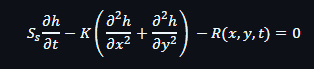

with:
- \(h(x,y,t)\): hydraulic head / water level
- \(S_s\): specific storage
- \(K\): hydraulic conductivity
- \(R\): source term, for example rainfall infiltration


## 1. Library Imports and GPU Configuration

This section automatically uses **CUDA/GPU** for PyTorch if available.
If a GPU is not available, the notebook still runs on CPU.


In [97]:

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import psutil
import imageio.v2 as imageio
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import traceback


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Faster on modern GPUs (Ampere, including RTX 3050)
torch.set_float32_matmul_precision("high")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
else:
    print("CUDA is not available, training will run on CPU.")

# ================================
# RAM information (System Memory)
# ================================
ram = psutil.virtual_memory()

print("\n===== SYSTEM RAM =====")
print(f"Total RAM     : {ram.total / (1024**3):.2f} GB")
print(f"Available RAM : {ram.available / (1024**3):.2f} GB")
print(f"Used RAM      : {ram.used / (1024**3):.2f} GB")
print(f"RAM Usage     : {ram.percent} %")

# ================================
# GPU VRAM information
# ================================
if torch.cuda.is_available():
    gpu_id = torch.cuda.current_device()

    total_vram = torch.cuda.get_device_properties(gpu_id).total_memory
    allocated_vram = torch.cuda.memory_allocated(gpu_id)
    reserved_vram = torch.cuda.memory_reserved(gpu_id)

    print("\n===== GPU VRAM =====")
    print(f"GPU Name        : {torch.cuda.get_device_name(gpu_id)}")
    print(f"Total VRAM      : {total_vram / (1024**3):.2f} GB")
    print(f"Allocated VRAM  : {allocated_vram / (1024**3):.2f} GB")
    print(f"Reserved VRAM   : {reserved_vram / (1024**3):.2f} GB")
    print(f"Free VRAM       : {(total_vram - reserved_vram) / (1024**3):.2f} GB")
else:
    print("\nGPU is not available.")

Device in use: cuda
GPU name: NVIDIA GeForce RTX 3050

===== SYSTEM RAM =====
Total RAM     : 31.84 GB
Available RAM : 10.12 GB
Used RAM      : 21.73 GB
RAM Usage     : 68.2 %

===== GPU VRAM =====
GPU Name        : NVIDIA GeForce RTX 3050
Total VRAM      : 8.00 GB
Allocated VRAM  : 0.02 GB
Reserved VRAM   : 0.12 GB
Free VRAM       : 7.88 GB


## 2. Physical Parameters and Simulation Domain

**a. Domain length (m)**

`Lx` and `Ly` define the size of the two-dimensional simulation area. In this notebook, the domain remains fixed at `50 m × 50 m`.

**b. Time (hours)**

The simulation now uses **hours** instead of days so that it is more realistic for rainfall events.
- `T_end = 6.0` means the total simulation lasts 6 hours
- rainfall is active mainly from 0 to around 3 hours, then the system is allowed to respond until the end of the simulation

**c. Spatial grid**
- `Nx` = number of points in the `x` direction
- `Ny` = number of points in the `y` direction

With `Nx = Ny = 51`, the grid spacing becomes `1 m`.

**d. FDM time step**

`dt` is limited by the explicit-scheme stability condition and also by `TARGET_DT_HOURS` so the time resolution is fine enough for hourly rainfall events.

**e. Hydraulic conductivity**

In the code, `K_day` is still defined in `m/day`, then automatically converted to `K` in `m/hour` to stay consistent with the new time scale.

**f. Specific storage**

`Ss` represents the water storage capacity of the porous medium in this simplified model.


In [98]:
# ============================================================
# PHYSICAL PARAMETERS AND DOMAIN
# ============================================================
Lx, Ly = 50.0, 50.0                  # domain length (m)
TIME_UNIT_LABEL = "hours"
T_end = 6.0                          # total simulation time (hours), realistic for rainfall events

Nx, Ny = 51, 51                      # spatial grid
TARGET_DT_HOURS = 0.10               # target time resolution so hourly snapshots are sufficiently smooth
INITIAL_HEAD = 1.0                   # initial hydraulic head (m)
BOUNDARY_HEAD = 1.0                  # Dirichlet boundary head (m)

# Hydrologic parameters
K_day = 0.8                          # original hydraulic conductivity (m/day)
K = K_day / 24.0                     # converted to m/hour
Ss = 0.15                            # specific storage
D = K / Ss                           # simplified diffusivity (m^2/hour)

# Stability condition for the explicit 2D scheme: rx + ry <= 0.5
# where rx = D*dt/dx^2 and ry = D*dt/dy^2
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
dt_stable = 0.5 / (D * (1.0 / dx**2 + 1.0 / dy**2))
stability_safety = 0.90

dt = min(dt_stable * stability_safety, TARGET_DT_HOURS)
Nt = int(np.ceil(T_end / dt))
dt = T_end / Nt

t_arr = np.linspace(0, T_end, Nt + 1)
X, Y = np.meshgrid(x, y, indexing='ij')

def nearest_time_index(t_value):
    return int(np.argmin(np.abs(t_arr - float(t_value))))

print(f"dx={dx:.3f} m, dy={dy:.3f} m, dt={dt:.3f} {TIME_UNIT_LABEL}, Nt={Nt}")
print(f"dt_stable(max)={dt_stable:.3f} {TIME_UNIT_LABEL}, dt_target={TARGET_DT_HOURS:.3f} {TIME_UNIT_LABEL}, safety={stability_safety:.2f}")
print(f"K={K:.5f} m/hour (equivalent to {K_day:.3f} m/day), D={D:.5f} m^2/hour")


dx=1.000 m, dy=1.000 m, dt=0.100 hours, Nt=60
dt_stable(max)=1.125 hours, dt_target=0.100 hours, safety=0.90
K=0.03333 m/hour (equivalent to 0.800 m/day), D=0.22222 m^2/hour


## 3. Multi-Point Rainfall Infiltration Source Term, Initial Condition, and Boundary Condition


In [99]:
# ============================================================
# SOURCE TERM / MULTI-POINT RAINFALL INFILTRATION
# ============================================================
RAIN_FIELD_CONFIG = {
    "seed": SEED + 8,
    "num_cells": 18,
    "x_margin_m": 4.0,
    "y_margin_m": 4.0,
    "sigma_range_m": (1.5, 3.8),
    "intensity_range_m_per_hour": (0.0015, 0.0040),
}

# If you want to modify the rainfall pattern manually, edit the variables below and then run refresh_rain_tensors().
_rain_rng = np.random.default_rng(RAIN_FIELD_CONFIG["seed"])
RAIN_CELL_CENTERS = np.column_stack([
    _rain_rng.uniform(RAIN_FIELD_CONFIG["x_margin_m"], Lx - RAIN_FIELD_CONFIG["x_margin_m"], size=RAIN_FIELD_CONFIG["num_cells"]),
    _rain_rng.uniform(RAIN_FIELD_CONFIG["y_margin_m"], Ly - RAIN_FIELD_CONFIG["y_margin_m"], size=RAIN_FIELD_CONFIG["num_cells"]),
]).astype(np.float64)
RAIN_CELL_SIGMAS = _rain_rng.uniform(*RAIN_FIELD_CONFIG["sigma_range_m"], size=RAIN_FIELD_CONFIG["num_cells"]).astype(np.float64)
RAIN_CELL_INTENSITIES = _rain_rng.uniform(*RAIN_FIELD_CONFIG["intensity_range_m_per_hour"], size=RAIN_FIELD_CONFIG["num_cells"]).astype(np.float64)

# All simulations use a fully active rainfall event for 6 hours.
RAIN_TIME_BREAKPOINTS_HOURS = np.array([0.0, 0.8, 1.6, 2.4, 3.2, 4.0, 4.8, 5.4, T_end], dtype=np.float64)
RAIN_TIME_MULTIPLIERS = np.array([0.20, 0.45, 0.78, 1.00, 0.90, 0.72, 0.55, 0.35, 0.15], dtype=np.float64)

def refresh_rain_tensors():
    global RAIN_CENTERS_X_T, RAIN_CENTERS_Y_T, RAIN_SIGMAS_T, RAIN_INTENSITIES_T
    global RAIN_TIME_BREAKPOINTS_T, RAIN_TIME_MULTIPLIERS_T, RAIN_MARKER_SIZES

    RAIN_CENTERS_X_T = torch.tensor(RAIN_CELL_CENTERS[:, 0], dtype=torch.float32, device=device).view(1, -1)
    RAIN_CENTERS_Y_T = torch.tensor(RAIN_CELL_CENTERS[:, 1], dtype=torch.float32, device=device).view(1, -1)
    RAIN_SIGMAS_T = torch.tensor(RAIN_CELL_SIGMAS, dtype=torch.float32, device=device).view(1, -1)
    RAIN_INTENSITIES_T = torch.tensor(RAIN_CELL_INTENSITIES, dtype=torch.float32, device=device).view(1, -1)
    RAIN_TIME_BREAKPOINTS_T = torch.tensor(RAIN_TIME_BREAKPOINTS_HOURS, dtype=torch.float32, device=device)
    RAIN_TIME_MULTIPLIERS_T = torch.tensor(RAIN_TIME_MULTIPLIERS, dtype=torch.float32, device=device)

    peak_intensity = max(float(np.max(RAIN_CELL_INTENSITIES)), 1e-12)
    RAIN_MARKER_SIZES = 40.0 + 180.0 * (RAIN_CELL_INTENSITIES / peak_intensity)

refresh_rain_tensors()

print(f"Multi-point rainfall pattern: {len(RAIN_CELL_CENTERS)} random points")
print(
    f"All simulations use active rainfall from {RAIN_TIME_BREAKPOINTS_HOURS[0]:.1f}"
    f" - {RAIN_TIME_BREAKPOINTS_HOURS[-1]:.1f} hours."
)
print("Modify RAIN_CELL_CENTERS, RAIN_CELL_SIGMAS, RAIN_CELL_INTENSITIES, or RAIN_TIME_MULTIPLIERS and then run refresh_rain_tensors() to change the rainfall.")

def rainfall_temporal_profile_np(t):
    t_arr_local = np.asarray(t, dtype=np.float64)
    return np.interp(
        t_arr_local,
        RAIN_TIME_BREAKPOINTS_HOURS,
        RAIN_TIME_MULTIPLIERS,
        left=0.0,
        right=0.0,
    )

def rainfall_temporal_profile_torch(t):
    profile = torch.zeros_like(t)
    n_segments = len(RAIN_TIME_BREAKPOINTS_HOURS) - 1

    for i in range(n_segments):
        t0 = RAIN_TIME_BREAKPOINTS_T[i]
        t1 = RAIN_TIME_BREAKPOINTS_T[i + 1]
        v0 = RAIN_TIME_MULTIPLIERS_T[i]
        v1 = RAIN_TIME_MULTIPLIERS_T[i + 1]

        if i == n_segments - 1:
            mask = (t >= t0) & (t <= t1)
        else:
            mask = (t >= t0) & (t < t1)

        interp = v0 + (v1 - v0) * (t - t0) / torch.clamp(t1 - t0, min=1e-12)
        profile = torch.where(mask, interp, profile)

    return profile

def rainfall_source_np(X, Y, t):
    spatial = np.exp(
        -(
            (X[..., None] - RAIN_CELL_CENTERS[:, 0])**2
            + (Y[..., None] - RAIN_CELL_CENTERS[:, 1])**2
        ) / (2.0 * RAIN_CELL_SIGMAS**2)
    )
    base_rain = np.sum(spatial * RAIN_CELL_INTENSITIES.reshape(1, 1, -1), axis=2)
    temporal = rainfall_temporal_profile_np(t)
    return base_rain * temporal

def rainfall_source_torch(x, y, t):
    spatial = torch.exp(
        -(
            (x - RAIN_CENTERS_X_T)**2
            + (y - RAIN_CENTERS_Y_T)**2
        ) / (2.0 * RAIN_SIGMAS_T**2)
    )
    base_rain = torch.sum(spatial * RAIN_INTENSITIES_T, dim=1, keepdim=True)
    temporal = rainfall_temporal_profile_torch(t)
    return base_rain * temporal

# ============================================================
# INITIAL AND BOUNDARY CONDITIONS
# ============================================================
def initial_condition_np(X, Y):
    return np.ones_like(X) * INITIAL_HEAD

def initial_condition_torch(x, y):
    return torch.ones_like(x) * INITIAL_HEAD

def boundary_value_torch(x, y, t):
    return torch.ones_like(x) * BOUNDARY_HEAD

Multi-point rainfall pattern: 18 random points
All simulations use active rainfall from 0.0 - 6.0 hours.
Modify RAIN_CELL_CENTERS, RAIN_CELL_SIGMAS, RAIN_CELL_INTENSITIES, or RAIN_TIME_MULTIPLIERS and then run refresh_rain_tensors() to change the rainfall.


## 4. Finite Difference Method (FDM) Solver


In [100]:
# ============================================================
# SOLVER FDM
# ============================================================
def solve_fdm():
    '''
    Solves:
    dh/dt = D (d2h/dx2 + d2h/dy2) + R/Ss
    '''
    h = np.zeros((Nt + 1, Nx, Ny), dtype=np.float64)
    h[0] = initial_condition_np(X, Y)

    # Initial boundary values
    h[0, 0, :] = BOUNDARY_HEAD
    h[0, -1, :] = BOUNDARY_HEAD
    h[0, :, 0] = BOUNDARY_HEAD
    h[0, :, -1] = BOUNDARY_HEAD

    rx = D * dt / dx**2
    ry = D * dt / dy**2
    print(f"Stability indicators -> rx={rx:.4f}, ry={ry:.4f}, rx+ry={rx+ry:.4f}")

    if rx + ry > 0.5:
        print("WARNING: The explicit scheme may be unstable. Reduce dt or change the grid.")

    for n in range(Nt):
        hn = h[n].copy()
        hnew = hn.copy()
        source = rainfall_source_np(X, Y, t_arr[n]) / Ss

        hnew[1:-1, 1:-1] = (
            hn[1:-1, 1:-1]
            + rx * (hn[2:, 1:-1] - 2 * hn[1:-1, 1:-1] + hn[:-2, 1:-1])
            + ry * (hn[1:-1, 2:] - 2 * hn[1:-1, 1:-1] + hn[1:-1, :-2])
            + dt * source[1:-1, 1:-1]
        )

        # Dirichlet boundary
        hnew[0, :] = BOUNDARY_HEAD
        hnew[-1, :] = BOUNDARY_HEAD
        hnew[:, 0] = BOUNDARY_HEAD
        hnew[:, -1] = BOUNDARY_HEAD

        h[n + 1] = hnew

    return h


## 5. Neural Network and PINN Architecture with PyTorch and GPU


In [101]:
# ============================================================
# NEURAL NETWORK AND PINN MODELS
# ============================================================
class HydraulicHeadMLP(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=96, num_hidden=5, out_dim=1):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, xyt):
        # Normalize inputs for more stable training
        x = xyt[:, 0:1] / Lx
        y = xyt[:, 1:2] / Ly
        t = xyt[:, 2:3] / T_end
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)


class NeuralNetworkSurrogate(HydraulicHeadMLP):
    pass


class PINN(HydraulicHeadMLP):
    pass


def pinn_residual(model, x, y, t):
    # Residual PDE: Ss*h_t - K*(h_xx + h_yy) - R = 0
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    inp = torch.cat([x, y, t], dim=1)
    h = model(inp)

    h_x = torch.autograd.grad(h, x, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]
    h_y = torch.autograd.grad(h, y, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]
    h_t = torch.autograd.grad(h, t, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]

    h_xx = torch.autograd.grad(h_x, x, grad_outputs=torch.ones_like(h_x), create_graph=True, retain_graph=True)[0]
    h_yy = torch.autograd.grad(h_y, y, grad_outputs=torch.ones_like(h_y), create_graph=True, retain_graph=True)[0]

    R = rainfall_source_torch(x, y, t)
    residual = Ss * h_t - K * (h_xx + h_yy) - R
    return residual

## 6. PINN Training-Point Sampling and Dummy Observation Data for the Data-Driven Model


In [102]:
# ============================================================
# PINN TRAINING DATA SAMPLING
# ============================================================
def sample_interior(n):
    x = torch.rand((n, 1), device=device) * Lx
    y = torch.rand((n, 1), device=device) * Ly
    t = torch.rand((n, 1), device=device) * T_end
    return x, y, t

def sample_initial(n):
    x = torch.rand((n, 1), device=device) * Lx
    y = torch.rand((n, 1), device=device) * Ly
    t = torch.zeros((n, 1), device=device)
    h0 = initial_condition_torch(x, y)
    return x, y, t, h0

def sample_boundary(n):
    n_side = n // 4

    # x = 0
    x1 = torch.zeros((n_side, 1), device=device)
    y1 = torch.rand((n_side, 1), device=device) * Ly
    t1 = torch.rand((n_side, 1), device=device) * T_end

    # x = Lx
    x2 = torch.ones((n_side, 1), device=device) * Lx
    y2 = torch.rand((n_side, 1), device=device) * Ly
    t2 = torch.rand((n_side, 1), device=device) * T_end

    # y = 0
    x3 = torch.rand((n_side, 1), device=device) * Lx
    y3 = torch.zeros((n_side, 1), device=device)
    t3 = torch.rand((n_side, 1), device=device) * T_end

    # y = Ly
    x4 = torch.rand((n_side, 1), device=device) * Lx
    y4 = torch.ones((n_side, 1), device=device) * Ly
    t4 = torch.rand((n_side, 1), device=device) * T_end

    x = torch.cat([x1, x2, x3, x4], dim=0)
    y = torch.cat([y1, y2, y3, y4], dim=0)
    t = torch.cat([t1, t2, t3, t4], dim=0)
    hb = boundary_value_torch(x, y, t)
    return x, y, t, hb

DUMMY_PINN_DATA_CONFIG = {
    "times_hours": np.array([1.0, 2.0, 3.0], dtype=np.float64),
    "sensor_points_xy_m": np.array([
        [6.0, 8.0],
        [12.0, 14.0],
        [19.0, 9.0],
        [27.0, 15.0],
        [35.0, 10.0],
        [43.0, 18.0],
        [8.0, 27.0],
        [16.0, 34.0],
        [24.0, 26.0],
        [32.0, 37.0],
        [40.0, 29.0],
        [22.0, 43.0],
    ], dtype=np.float64),
    "hourly_bias_m": np.array([0.003, 0.007, 0.010], dtype=np.float64),
    "noise_std_m": 0.003,
    "seed": SEED + 17,
    "note": (
        "NOTE: DUMMY_PINN_OBSERVATIONS contains dummy data at hours 1, 2, and 3. "
        "These data are used to train the Neural Network and PINN, and the models are then evaluated "
        "to predict hours 4 to 6."
    ),
}

DUMMY_PINN_OBSERVATIONS = None

def sample_field_at_sensor_points(field, sensor_points_xy_m):
    sensor_points_xy_m = np.asarray(sensor_points_xy_m, dtype=np.float64)
    ix = np.clip(np.rint(sensor_points_xy_m[:, 0] / dx).astype(int), 0, Nx - 1)
    iy = np.clip(np.rint(sensor_points_xy_m[:, 1] / dy).astype(int), 0, Ny - 1)
    return field[ix, iy]

def build_dummy_pinn_observation_data(h_fdm):
    cfg = DUMMY_PINN_DATA_CONFIG
    times = np.asarray(cfg["times_hours"], dtype=np.float64)
    sensor_points = np.asarray(cfg["sensor_points_xy_m"], dtype=np.float64)
    hourly_bias = np.asarray(cfg["hourly_bias_m"], dtype=np.float64)

    if len(times) != len(hourly_bias):
        raise ValueError("times_hours and hourly_bias_m must have the same length.")

    rng = np.random.default_rng(cfg["seed"])
    observed_rows = []
    reference_rows = []
    matched_times = []

    for hour, bias in zip(times, hourly_bias):
        idx = nearest_time_index(hour)
        ref_vals = sample_field_at_sensor_points(h_fdm[idx], sensor_points)
        noise = rng.normal(loc=0.0, scale=cfg["noise_std_m"], size=ref_vals.shape)
        obs_vals = np.clip(ref_vals + bias + noise, BOUNDARY_HEAD, None)

        reference_rows.append(ref_vals)
        observed_rows.append(obs_vals)
        matched_times.append(float(t_arr[idx]))

    return {
        "note": cfg["note"],
        "times_hours": times.copy(),
        "matched_time_hours": np.asarray(matched_times, dtype=np.float64),
        "sensor_points_xy_m": sensor_points.copy(),
        "hourly_bias_m": hourly_bias.copy(),
        "noise_std_m": float(cfg["noise_std_m"]),
        "fdm_reference_m": np.asarray(reference_rows, dtype=np.float64),
        "observed_head_m": np.asarray(observed_rows, dtype=np.float64),
    }

def describe_dummy_pinn_observations(obs_data):
    print(obs_data["note"])
    print("Dummy observation times for training (hours):", obs_data["times_hours"])
    print("FDM grid times used (hours):", obs_data["matched_time_hours"])
    print("Dummy sensor coordinates (x, y) [m]:")
    print(np.array2string(obs_data["sensor_points_xy_m"], precision=2, suppress_small=True))
    print("Dummy head values for data-driven model training [m] (rows = hours, columns = sensors):")
    print(np.array2string(obs_data["observed_head_m"], precision=4, suppress_small=True))

def observation_data_to_torch(obs_data):
    times = np.asarray(obs_data["times_hours"], dtype=np.float32)
    sensor_points = np.asarray(obs_data["sensor_points_xy_m"], dtype=np.float32)
    observed_head = np.asarray(obs_data["observed_head_m"], dtype=np.float32)

    expected_shape = (len(times), len(sensor_points))
    if observed_head.shape != expected_shape:
        raise ValueError(
            f"observed_head_m must have shape {expected_shape}, but got {observed_head.shape}."
        )

    x_obs = np.tile(sensor_points[:, 0], len(times)).reshape(-1, 1)
    y_obs = np.tile(sensor_points[:, 1], len(times)).reshape(-1, 1)
    t_obs = np.repeat(times, len(sensor_points)).reshape(-1, 1)
    h_obs = observed_head.reshape(-1, 1)

    return (
        torch.tensor(x_obs, dtype=torch.float32, device=device),
        torch.tensor(y_obs, dtype=torch.float32, device=device),
        torch.tensor(t_obs, dtype=torch.float32, device=device),
        torch.tensor(h_obs, dtype=torch.float32, device=device),
    )

def initial_condition_grid_to_torch(stride=2):
    X0 = X[::stride, ::stride]
    Y0 = Y[::stride, ::stride]
    H0 = initial_condition_np(X0, Y0)
    T0 = np.zeros_like(H0)

    return (
        torch.tensor(X0.reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor(Y0.reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor(T0.reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor(H0.reshape(-1, 1), dtype=torch.float32, device=device),
    )

## 7. Neural Network and PINN Training Definitions on GPU


In [103]:
# ============================================================
# NEURAL NETWORK AND PINN TRAINING
# ============================================================
def train_neural_network(
    epochs_adam=5000,
    epochs_lbfgs=250,
    initial_stride=2,
    lr=1e-3,
    obs_data=None,
    w_ini=15.0,
    w_data=35.0,
):
    model = NeuralNetworkSurrogate(hidden_dim=128, num_hidden=4).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(epochs_adam // 3, 1), gamma=0.5)

    x0, y0, t0, h0 = initial_condition_grid_to_torch(stride=initial_stride)
    obs_tensors = observation_data_to_torch(obs_data) if obs_data is not None else None
    history = []

    for epoch in range(1, epochs_adam + 1):
        optimizer.zero_grad(set_to_none=True)

        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0) ** 2)

        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho) ** 2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_ini * loss_ini + w_data * loss_data
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"[NN-Adam] Epoch {epoch:5d} | "
                f"Total={loss.item():.6e} | "
                f"IC={loss_ini.item():.6e} | "
                f"DATA={loss_data.item():.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    if epochs_lbfgs > 0:
        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors

        lbfgs = optim.LBFGS(
            model.parameters(),
            lr=0.6,
            max_iter=epochs_lbfgs,
            tolerance_grad=1e-9,
            tolerance_change=1e-11,
            history_size=50,
            line_search_fn='strong_wolfe',
        )

        def closure():
            lbfgs.zero_grad(set_to_none=True)

            pred0 = model(torch.cat([x0, y0, t0], dim=1))
            loss_ini = torch.mean((pred0 - h0) ** 2)

            if obs_tensors is not None:
                predo = model(torch.cat([xo, yo, to], dim=1))
                loss_data = torch.mean((predo - ho) ** 2)
            else:
                loss_data = torch.zeros(1, device=device)

            loss = w_ini * loss_ini + w_data * loss_data
            loss.backward()
            return loss

        final_loss = lbfgs.step(closure)
        final_loss_value = float(final_loss.detach().cpu()) if torch.is_tensor(final_loss) else float(final_loss)
        history.append(final_loss_value)
        print(f"[NN-LBFGS] Final loss={final_loss_value:.6e}")

    return model, history


def train_pinn(
    epochs_adam=8000,
    epochs_lbfgs=300,
    n_int=2500,
    n_ini=1200,
    n_bnd=1200,
    lr=8e-4,
    w_pde=1.0,
    w_ini=25.0,
    w_bnd=25.0,
    obs_data=None,
    w_data=30.0,
):
    model = PINN(hidden_dim=96, num_hidden=5).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)
    obs_tensors = observation_data_to_torch(obs_data) if obs_data is not None else None

    history = []

    for epoch in range(1, epochs_adam + 1):
        optimizer.zero_grad(set_to_none=True)

        xi, yi, ti = sample_interior(n_int)
        res = pinn_residual(model, xi, yi, ti)
        loss_pde = torch.mean(res**2)

        x0, y0, t0, h0 = sample_initial(n_ini)
        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0)**2)

        xb, yb, tb, hb = sample_boundary(n_bnd)
        predb = model(torch.cat([xb, yb, tb], dim=1))
        loss_bnd = torch.mean((predb - hb)**2)

        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho)**2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_pde * loss_pde + w_ini * loss_ini + w_bnd * loss_bnd + w_data * loss_data
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"[PINN-Adam] Epoch {epoch:5d} | "
                f"Total={loss.item():.6e} | "
                f"PDE={loss_pde.item():.6e} | "
                f"IC={loss_ini.item():.6e} | "
                f"BC={loss_bnd.item():.6e} | "
                f"DATA={loss_data.item():.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    lbfgs = optim.LBFGS(
        model.parameters(),
        lr=0.6,
        max_iter=epochs_lbfgs,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn='strong_wolfe'
    )

    xi, yi, ti = sample_interior(n_int)
    x0, y0, t0, h0 = sample_initial(n_ini)
    xb, yb, tb, hb = sample_boundary(n_bnd)

    if obs_tensors is not None:
        xo, yo, to, ho = obs_tensors

    def closure():
        lbfgs.zero_grad(set_to_none=True)

        res = pinn_residual(model, xi, yi, ti)
        loss_pde = torch.mean(res**2)

        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0)**2)

        predb = model(torch.cat([xb, yb, tb], dim=1))
        loss_bnd = torch.mean((predb - hb)**2)

        if obs_tensors is not None:
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho)**2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_pde * loss_pde + w_ini * loss_ini + w_bnd * loss_bnd + w_data * loss_data
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    final_loss_value = float(final_loss.detach().cpu()) if torch.is_tensor(final_loss) else float(final_loss)
    history.append(final_loss_value)
    print(f"[PINN-LBFGS] Final loss={final_loss_value:.6e}")

    return model, history

## 8. Neural Network and PINN Model Evaluation


In [104]:
# ============================================================
# MODEL EVALUATION ON THE GRID
# ============================================================
def predict_model(model, t_eval):
    XX, YY = np.meshgrid(x, y, indexing='ij')

    x_t = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device)
    y_t = torch.tensor(YY.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.full_like(x_t, float(t_eval), device=device)

    model.eval()
    with torch.no_grad():
        pred = model(torch.cat([x_t, y_t, t_t], dim=1)).detach().cpu().numpy()

    return pred.reshape(Nx, Ny)

def predict_neural_network(model, t_eval):
    return predict_model(model, t_eval)

def predict_pinn(model, t_eval):
    return predict_model(model, t_eval)

def regression_metrics(reference_field, predicted_field):
    error = predicted_field - reference_field
    return {
        'rmse_m': float(np.sqrt(np.mean(error**2))),
        'mae_m': float(np.mean(np.abs(error))),
        'max_abs_err_m': float(np.max(np.abs(error))),
    }

## 9. Visualization Functions


In [105]:
# ============================================================
# VISUALIZATION
# ============================================================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FLOW_CMAP = 'viridis'
DISPLAY_FIGSIZE = (13.0, 9.6)
FRAME_FIGSIZE = (11.0, 8.8)

def _observation_points_xy():
    obs_data = globals().get("DUMMY_PINN_OBSERVATIONS")
    if isinstance(obs_data, dict) and "sensor_points_xy_m" in obs_data:
        points = np.asarray(obs_data["sensor_points_xy_m"], dtype=np.float64)
        if points.ndim == 2 and points.shape[1] == 2:
            return points
    return np.empty((0, 2), dtype=np.float64)

def _plot_rain_markers(ax):
    ax.scatter(
        RAIN_CELL_CENTERS[:, 0],
        RAIN_CELL_CENTERS[:, 1],
        s=RAIN_MARKER_SIZES,
        c='deepskyblue',
        alpha=0.35,
        edgecolors='white',
        linewidths=0.7,
        zorder=5,
    )

def _plot_observation_markers(ax):
    obs_points = _observation_points_xy()
    if obs_points.size:
        ax.scatter(
            obs_points[:, 0],
            obs_points[:, 1],
            c='white',
            marker='s',
            s=28,
            edgecolors='black',
            linewidths=0.6,
            zorder=6,
        )

def _legend_handles(mode='flow'):
    handles = []

    if mode == 'flow':
        handles.extend([
            Patch(facecolor='#440154', edgecolor='k', label='Low head (drier zone / lower pressure)'),
            Patch(facecolor='#21918c', edgecolor='k', label='Medium head'),
            Patch(facecolor='#fde725', edgecolor='k', label='High head (wetter zone / higher pressure)'),
        ])

    handles.append(
        Line2D([0], [0], marker='o', color='white', markerfacecolor='deepskyblue',
               markeredgecolor='white', linestyle='None', markersize=8,
               label='Random rainfall points (forcing)')
    )

    if _observation_points_xy().size:
        handles.append(
            Line2D([0], [0], marker='s', color='black', markerfacecolor='white',
                   linestyle='None', markersize=6, label='Dummy observation points')
        )

    return handles

def _configure_domain_axes(ax, title):
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title)
    ax.set_xlim(0.0, Lx)
    ax.set_ylim(0.0, Ly)
    ax.set_aspect('equal', adjustable='box')
    if hasattr(ax, 'set_box_aspect'):
        ax.set_box_aspect(1)

def _draw_field_figure(
    field,
    title,
    vmin=None,
    vmax=None,
    cmap=FLOW_CMAP,
    colorbar_label='Hydraulic head h (m)',
    legend_mode='flow',
    figsize=DISPLAY_FIGSIZE,
):
    fig = plt.figure(figsize=figsize, facecolor='white')
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[1.0, 0.05],
        height_ratios=[1.0, 0.34],
        left=0.08,
        right=0.97,
        bottom=0.08,
        top=0.93,
        wspace=0.12,
        hspace=0.16,
    )
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_leg = fig.add_subplot(gs[1, :])

    cf = ax.contourf(X, Y, field, levels=80, vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.set_label(colorbar_label)
    cbar.ax.set_title('Low -> High', fontsize=9, pad=8)

    _plot_rain_markers(ax)
    _plot_observation_markers(ax)
    _configure_domain_axes(ax, title)

    ax_leg.axis('off')
    handles = _legend_handles(mode=legend_mode)
    leg = ax_leg.legend(
        handles=handles,
        loc='upper left',
        bbox_to_anchor=(0.0, 1.0),
        fontsize=9,
        framealpha=0.95,
        title='Legend',
        title_fontsize=10,
        borderpad=0.8,
        labelspacing=0.9,
        handlelength=1.6,
        handletextpad=0.8,
    )
    leg.get_frame().set_edgecolor('black')

    return fig, ax, cax, ax_leg

def plot_result(field, title, vmin=None, vmax=None, cmap=FLOW_CMAP, colorbar_label='Hydraulic head h (m)', legend_mode='flow'):
    fig, ax, cax, ax_leg = _draw_field_figure(
        field,
        title,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        colorbar_label=colorbar_label,
        legend_mode=legend_mode,
        figsize=DISPLAY_FIGSIZE,
    )
    plt.show()
    plt.close(fig)

def plot_history(history, title='Training Loss', label='Total loss'):
    plt.figure(figsize=(7, 4))
    plt.plot(history, label=label)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close()


## 10. Run the FDM Simulation


Stability indicators -> rx=0.0222, ry=0.0222, rx+ry=0.0444
All simulations use an active rainfall event from 0.0 to 6.0 hours.
NOTE: DUMMY_PINN_OBSERVATIONS contains dummy data at hours 1, 2, and 3. These data are used to train the Neural Network and PINN, and the models are then evaluated to predict hours 4 to 6.
Dummy observation times for training (hours): [1. 2. 3.]
FDM grid times used (hours): [1. 2. 3.]
Dummy sensor coordinates (x, y) [m]:
[[ 6.  8.]
 [12. 14.]
 [19.  9.]
 [27. 15.]
 [35. 10.]
 [43. 18.]
 [ 8. 27.]
 [16. 34.]
 [24. 26.]
 [32. 37.]
 [40. 29.]
 [22. 43.]]
Dummy head values for data-driven model training [m] (rows = hours, columns = sensors):
[[1.0022 1.0088 1.0088 1.0117 1.002  1.0062 1.0087 1.0104 1.0129 1.0044
  1.0119 1.0054]
 [1.0171 1.0104 1.005  1.0375 1.0109 1.0195 1.0285 1.0366 1.0142 1.0137
  1.0263 1.0079]
 [1.0214 1.0124 1.0136 1.0605 1.0235 1.0423 1.043  1.0752 1.0314 1.0156
  1.0384 1.0164]]


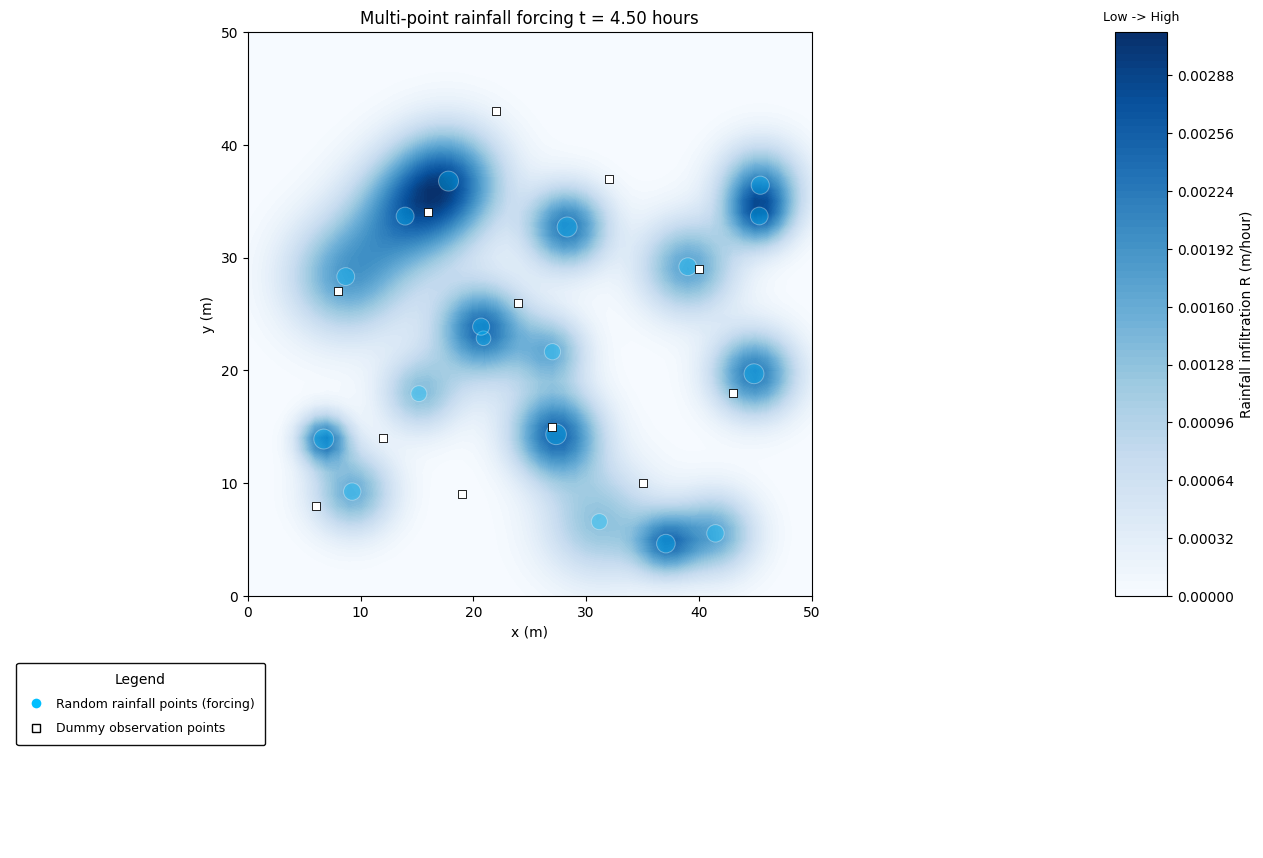

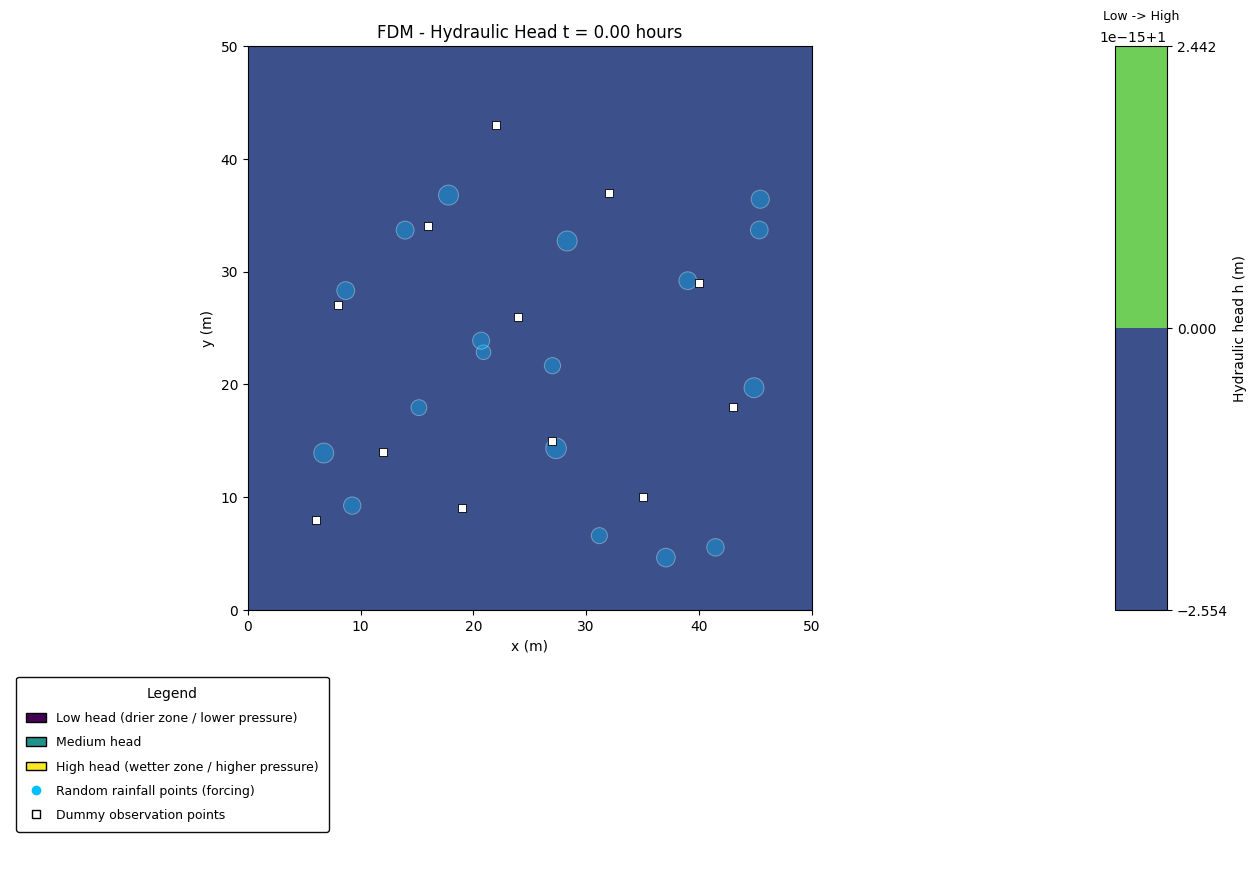

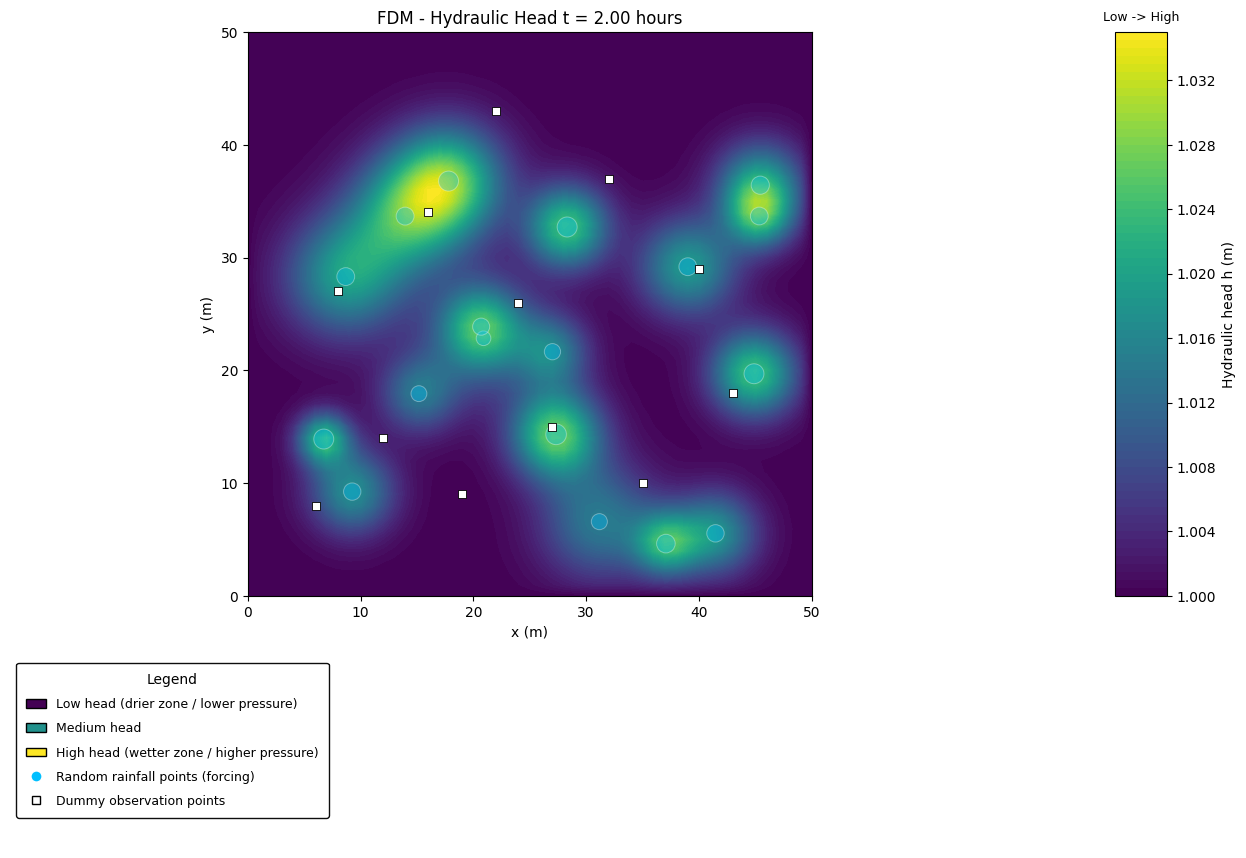

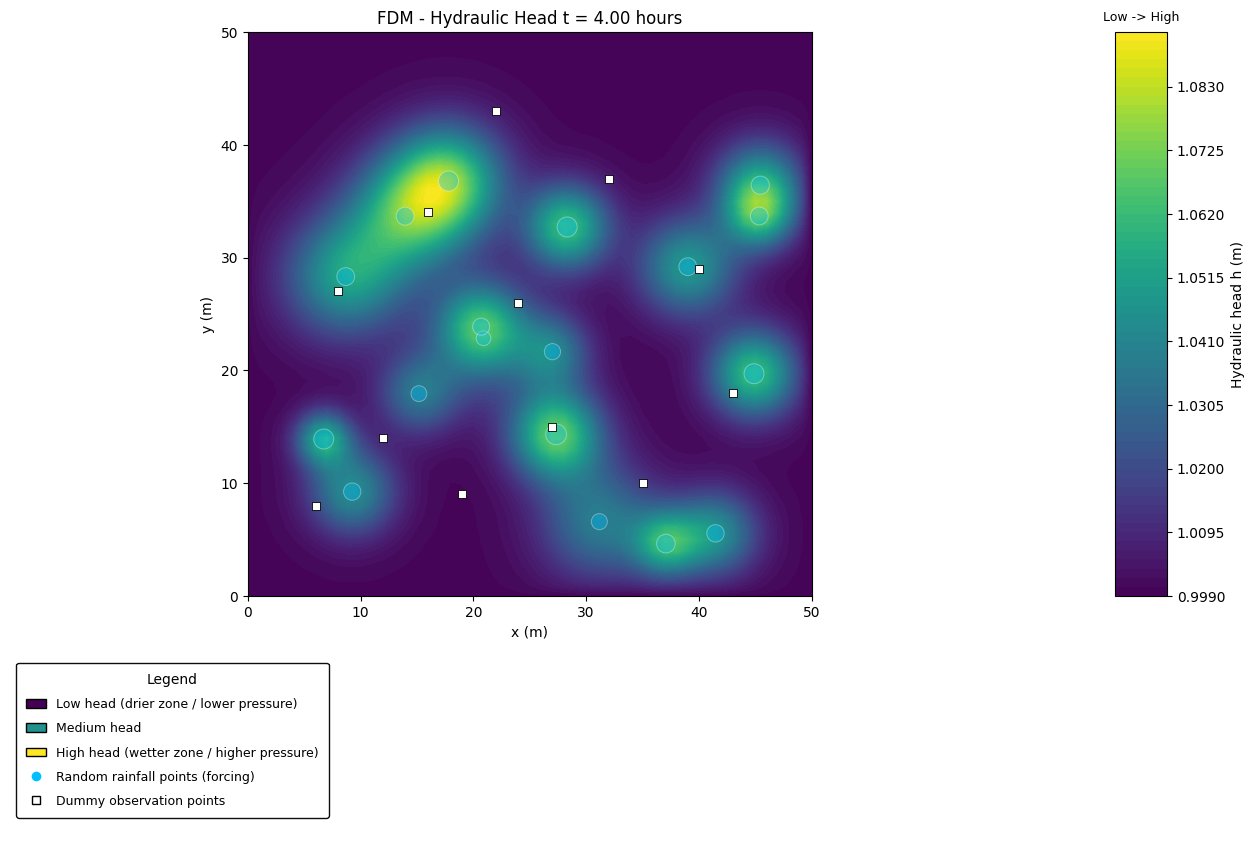

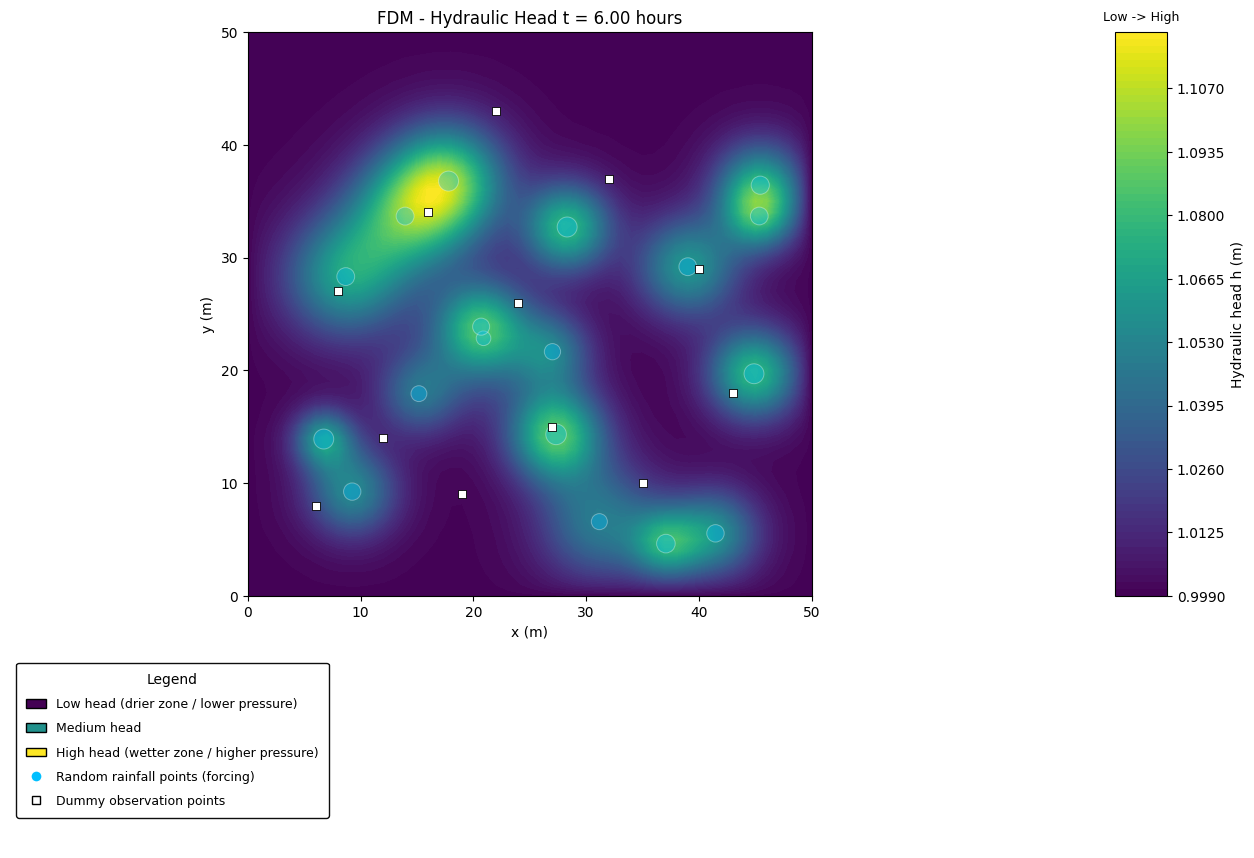

In [106]:
# Run FDM
h_fdm = solve_fdm()

print(f"All simulations use an active rainfall event from 0.0 to {T_end:.1f} hours.")

# Build dummy observation data for training the data-driven models
DUMMY_PINN_OBSERVATIONS = build_dummy_pinn_observation_data(h_fdm)
describe_dummy_pinn_observations(DUMMY_PINN_OBSERVATIONS)

# Plot multi-point rainfall forcing
plot_result(
    rainfall_source_np(X, Y, 4.5),
    "Multi-point rainfall forcing t = 4.50 hours",
    cmap='Blues',
    colorbar_label='Rainfall infiltration R (m/hour)',
    legend_mode='rain',
)

# Snapshot FDM
snapshot_hours = [0.0, 2.0, 4.0, T_end]
for t_plot in snapshot_hours:
    idx_plot = nearest_time_index(t_plot)
    plot_result(h_fdm[idx_plot], f"FDM - Hydraulic Head t = {t_arr[idx_plot]:.2f} hours")

## 11. Neural Network Training (Data-Driven)

Notes:
- This model does **not** use the PDE residual. It only fits the dummy data in `DUMMY_PINN_DATA_CONFIG` and the initial condition at `t = 0`.
- Dummy training data are only available at hours `1` to `3`.
- After training, the model is used to predict the next 3 hours, namely hours `4` to `6`.
- If a GPU is active, PyTorch training runs automatically on the GPU.
- If you want to speed up an initial test, reduce `epochs_adam` or `epochs_lbfgs`.


[NN-Adam] Epoch     1 | Total=4.630911e+01 | IC=8.861337e-01 | DATA=9.433458e-01 | LR=1.00e-03
[NN-Adam] Epoch   500 | Total=2.627135e-02 | IC=5.560917e-04 | DATA=5.122849e-04 | LR=1.00e-03
[NN-Adam] Epoch  1000 | Total=9.108217e-03 | IC=5.756076e-05 | DATA=2.355659e-04 | LR=1.00e-03
[NN-Adam] Epoch  1500 | Total=7.145337e-03 | IC=2.604773e-05 | DATA=1.929892e-04 | LR=1.00e-03
[NN-Adam] Epoch  2000 | Total=3.680292e-03 | IC=6.527217e-06 | DATA=1.023538e-04 | LR=5.00e-04
[NN-Adam] Epoch  2500 | Total=2.715007e-03 | IC=4.202448e-06 | DATA=7.577058e-05 | LR=5.00e-04
[NN-Adam] Epoch  3000 | Total=2.792366e-03 | IC=9.090886e-06 | DATA=7.588579e-05 | LR=5.00e-04
[NN-Adam] Epoch  3500 | Total=2.139433e-03 | IC=1.630947e-06 | DATA=6.042769e-05 | LR=2.50e-04
[NN-Adam] Epoch  4000 | Total=1.680287e-03 | IC=3.329943e-06 | DATA=4.658108e-05 | LR=2.50e-04
[NN-Adam] Epoch  4500 | Total=1.066723e-03 | IC=4.923632e-06 | DATA=2.836769e-05 | LR=2.50e-04
[NN-Adam] Epoch  5000 | Total=1.038490e-03 | IC=1.

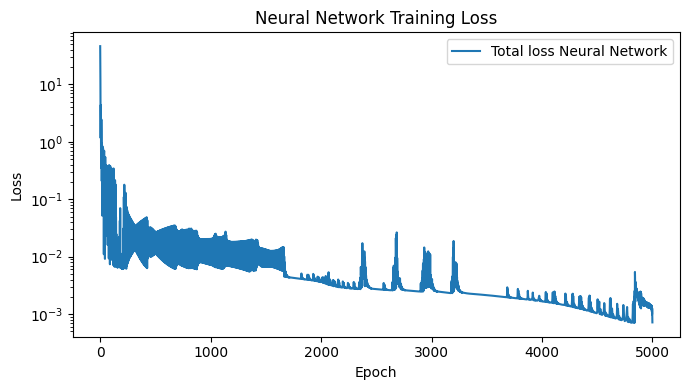

In [107]:
nn_model, nn_history = train_neural_network(
    epochs_adam=5000,
    epochs_lbfgs=250,
    initial_stride=2,
    lr=1e-3,
    obs_data=DUMMY_PINN_OBSERVATIONS,
    w_ini=15.0,
    w_data=35.0,
)

plot_history(
    nn_history,
    title='Neural Network Training Loss',
    label='Total loss Neural Network',
)

## 12. PINN Training

Notes:
- `DUMMY_PINN_OBSERVATIONS` only contains dummy data at hours `1` to `3`.
- The PINN uses PDE, initial-condition, boundary-condition, and dummy-observation losses.
- After training, the PINN is evaluated to predict conditions at hours `4` to `6`.
- Modify `DUMMY_PINN_DATA_CONFIG` to regenerate dummy data, or edit `DUMMY_PINN_OBSERVATIONS["observed_head_m"]` if you want to change the values manually.
- Replace these dummy data with actual field data so the PINN can simulate real conditions more accurately.
- If a GPU is active, PyTorch training runs automatically on the GPU.
- If you want to speed up an initial test, reduce `epochs_adam` or `epochs_lbfgs`.


[PINN-Adam] Epoch     1 | Total=6.378654e+01 | PDE=1.016600e-06 | IC=7.811944e-01 | BC=7.853736e-01 | DATA=8.207448e-01 | LR=8.00e-04
[PINN-Adam] Epoch   500 | Total=9.404404e-03 | PDE=1.590888e-06 | IC=4.034332e-05 | BC=1.090839e-04 | DATA=1.889044e-04 | LR=8.00e-04
[PINN-Adam] Epoch  1000 | Total=4.192947e-02 | PDE=1.698157e-06 | IC=5.003054e-04 | BC=3.270600e-04 | DATA=7.081211e-04 | LR=8.00e-04
[PINN-Adam] Epoch  1500 | Total=1.310718e-02 | PDE=1.719059e-06 | IC=8.462056e-05 | BC=1.842792e-04 | DATA=2.127656e-04 | LR=8.00e-04
[PINN-Adam] Epoch  2000 | Total=6.853107e-03 | PDE=1.568512e-06 | IC=1.909861e-05 | BC=6.788967e-05 | DATA=1.558944e-04 | LR=4.00e-04
[PINN-Adam] Epoch  2500 | Total=5.290781e-03 | PDE=1.089826e-06 | IC=6.119071e-06 | BC=5.653114e-05 | DATA=1.241145e-04 | LR=4.00e-04
[PINN-Adam] Epoch  3000 | Total=5.011420e-03 | PDE=8.912825e-07 | IC=2.805282e-05 | BC=2.490140e-05 | DATA=1.228891e-04 | LR=4.00e-04
[PINN-Adam] Epoch  3500 | Total=3.168443e-03 | PDE=8.842205e-0

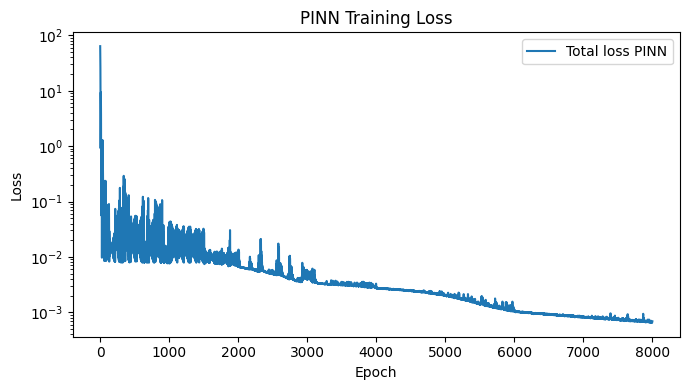

In [108]:
pinn_model, pinn_history = train_pinn(
    epochs_adam=8000,
    epochs_lbfgs=300,
    n_int=2500,
    n_ini=1200,
    n_bnd=1200,
    lr=8e-4,
    obs_data=DUMMY_PINN_OBSERVATIONS,
    w_data=30.0,
)

plot_history(
    pinn_history,
    title='PINN Training Loss',
    label='Total loss PINN',
)

## 13. Comparison of FDM vs Neural Network vs PINN Results


Evaluating the next 3-hour prediction horizon against the FDM reference:


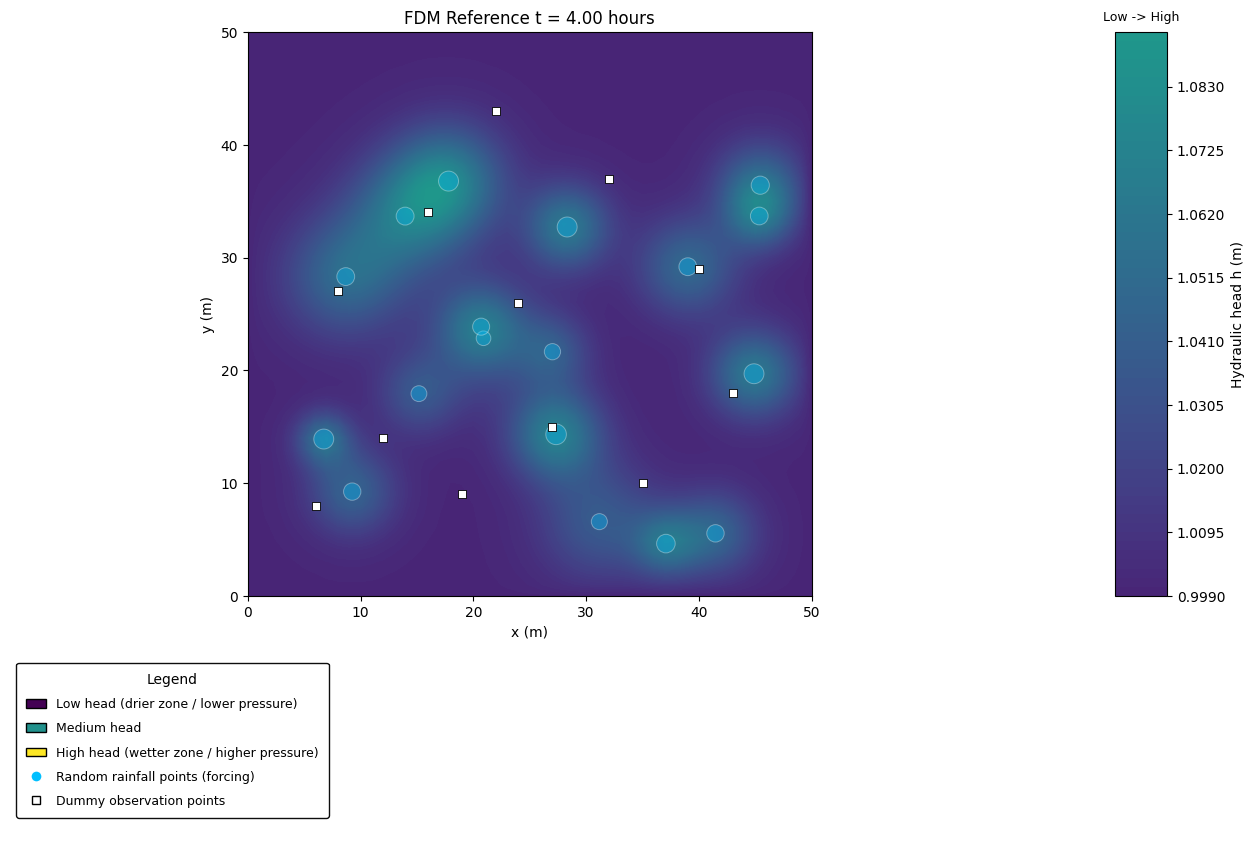

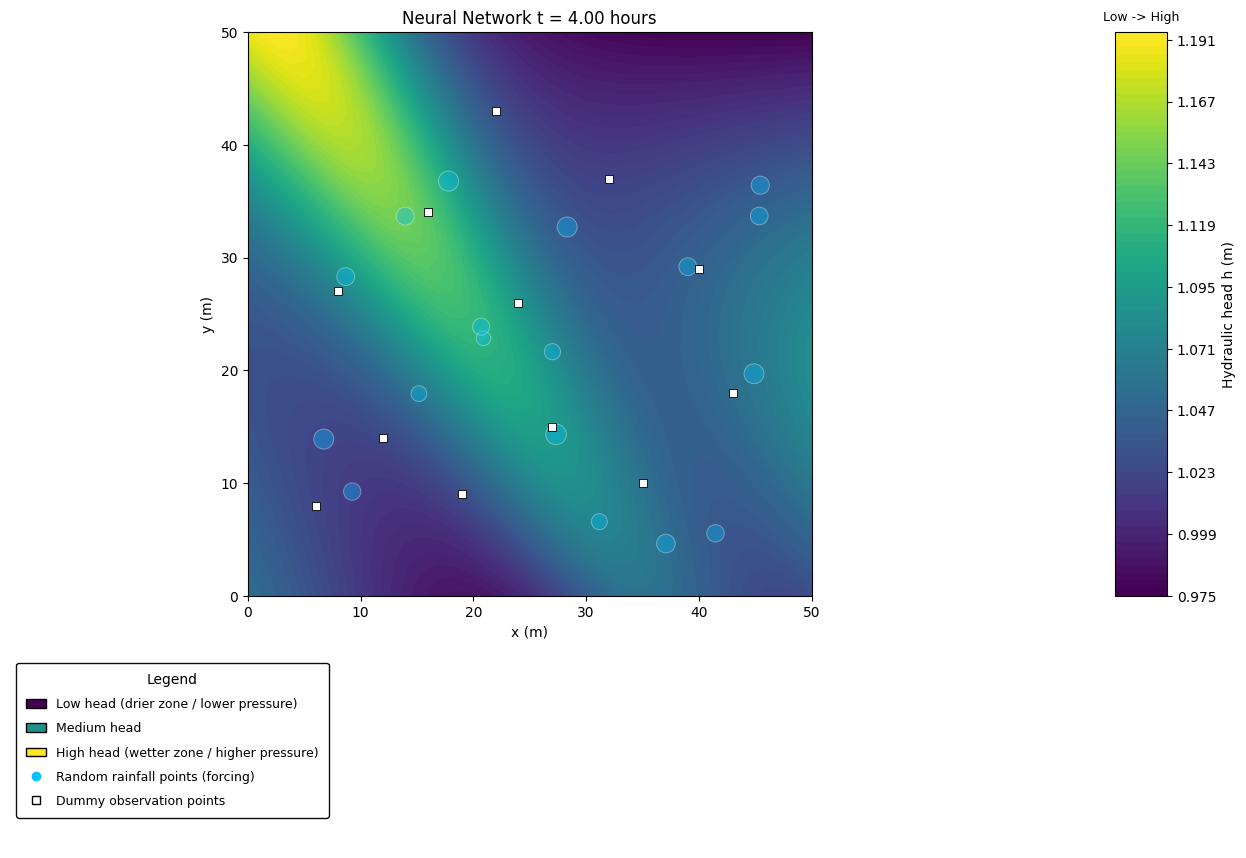

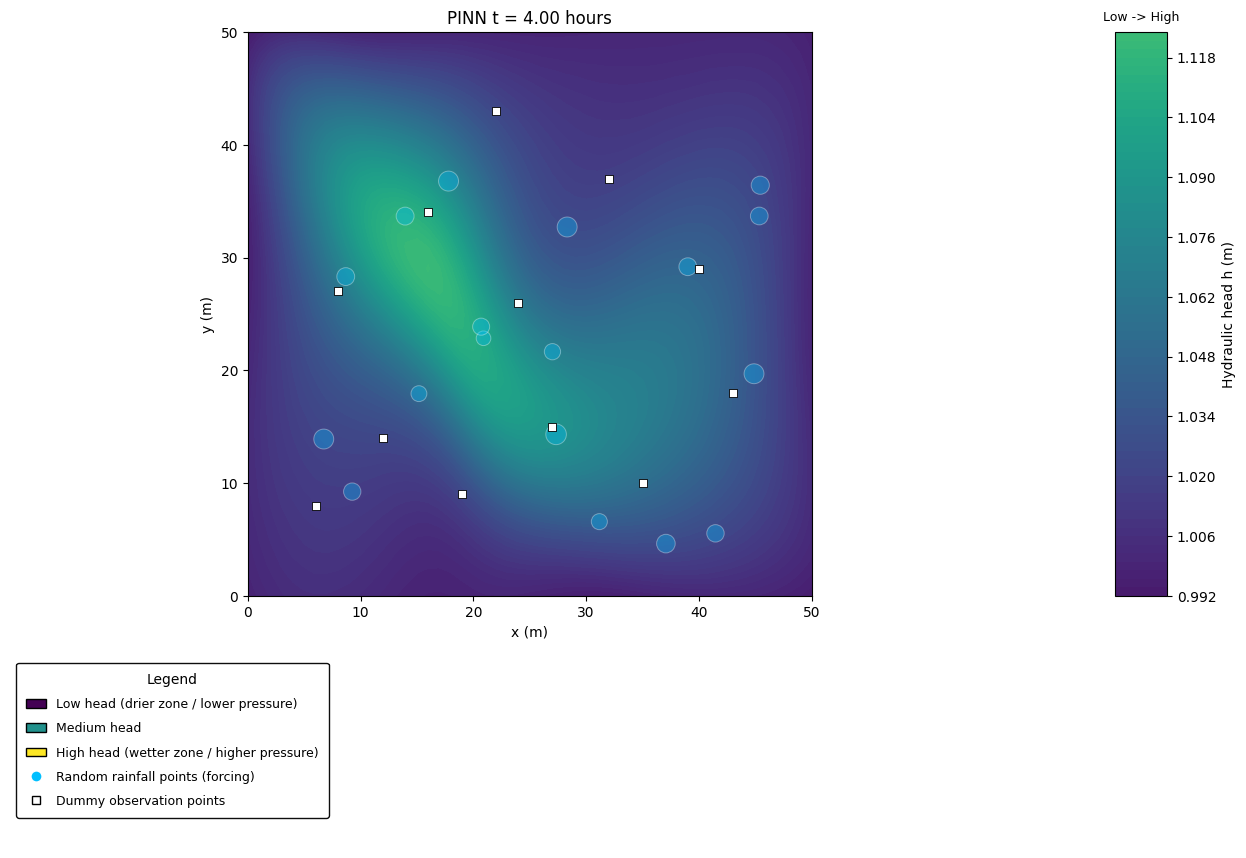

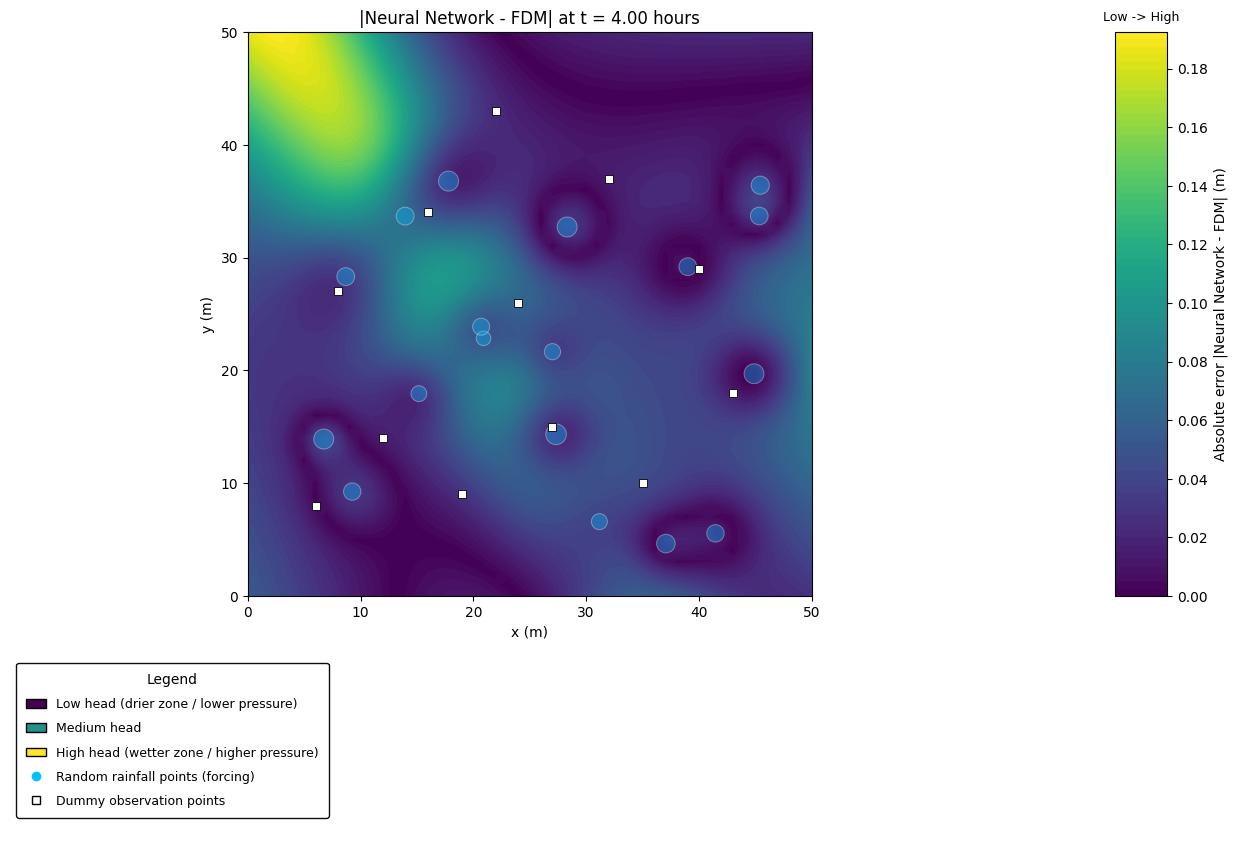

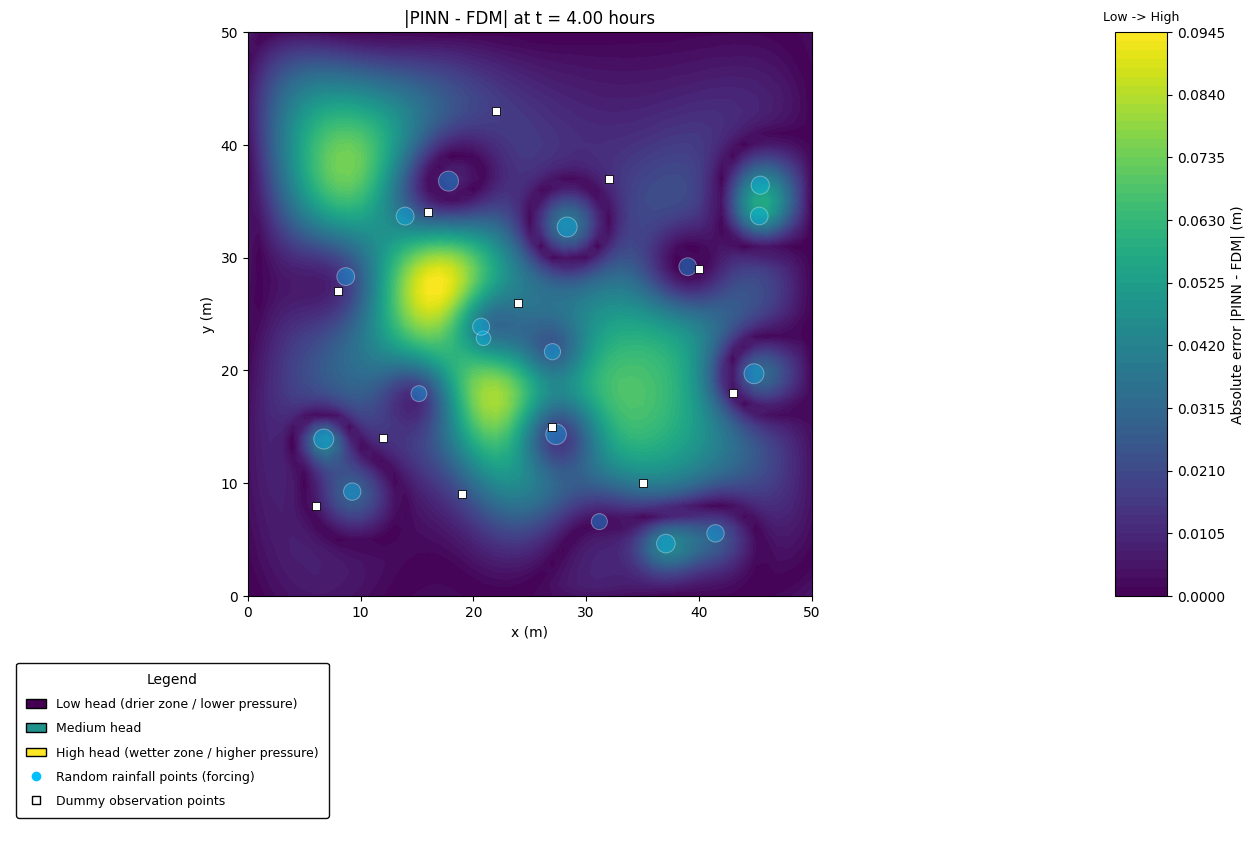

t=4.00 hours | NN -> RMSE=0.057100, MAE=0.041899, MAX=0.192172 | PINN -> RMSE=0.030723, MAE=0.022612, MAX=0.094384


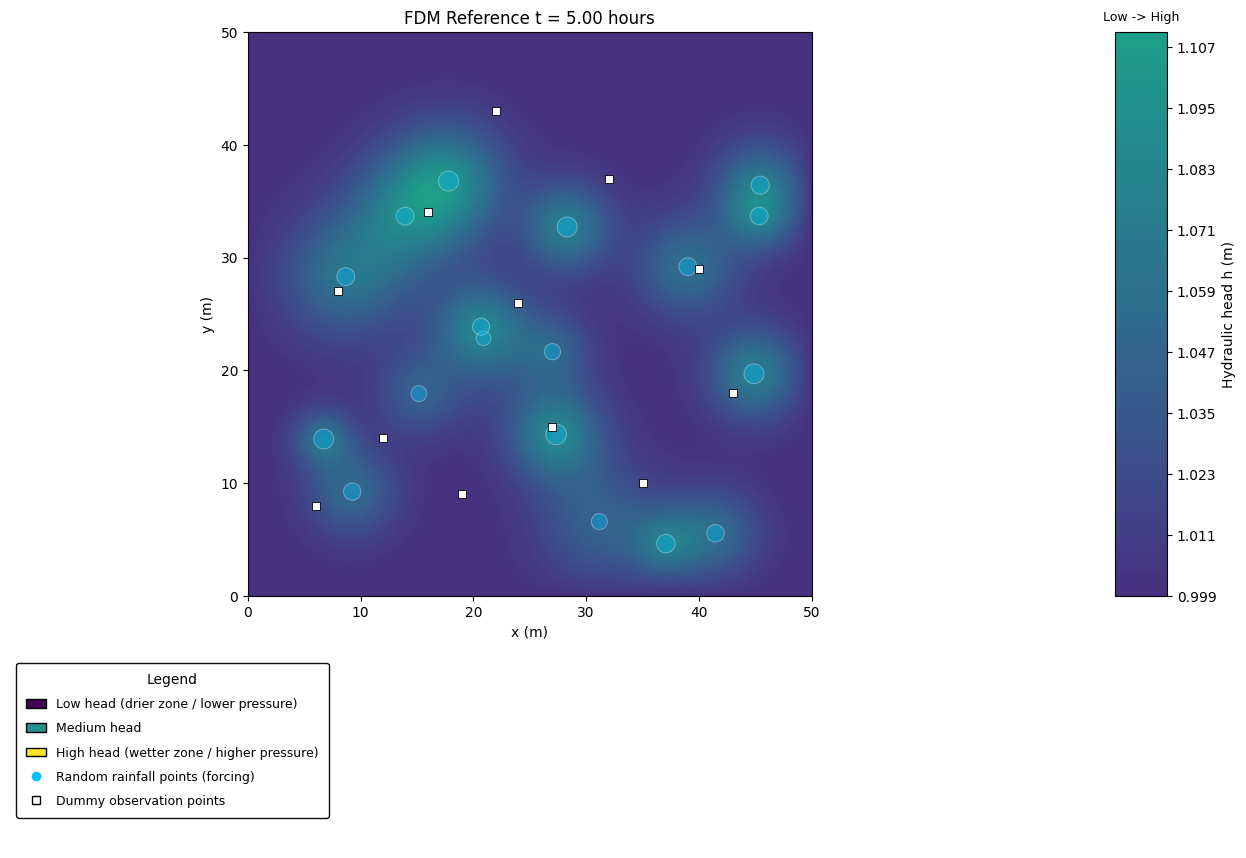

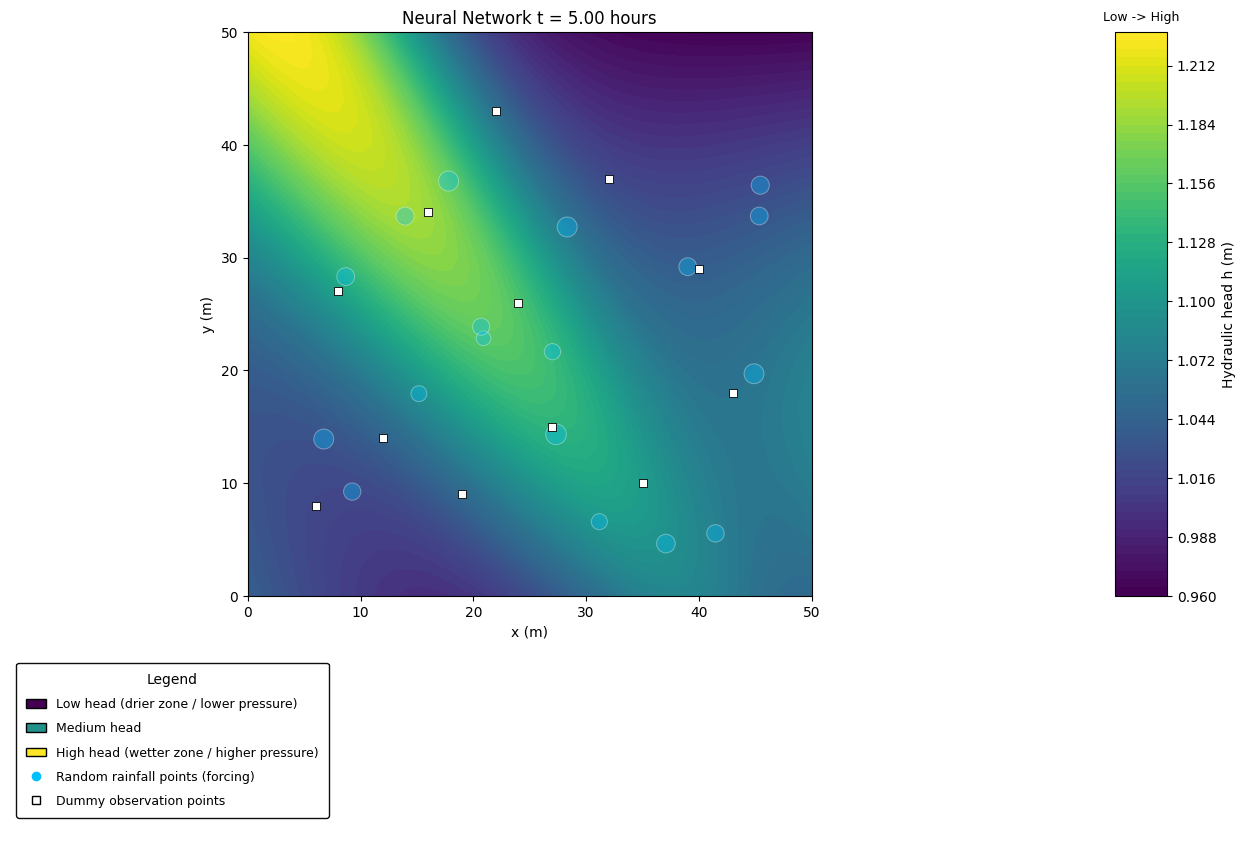

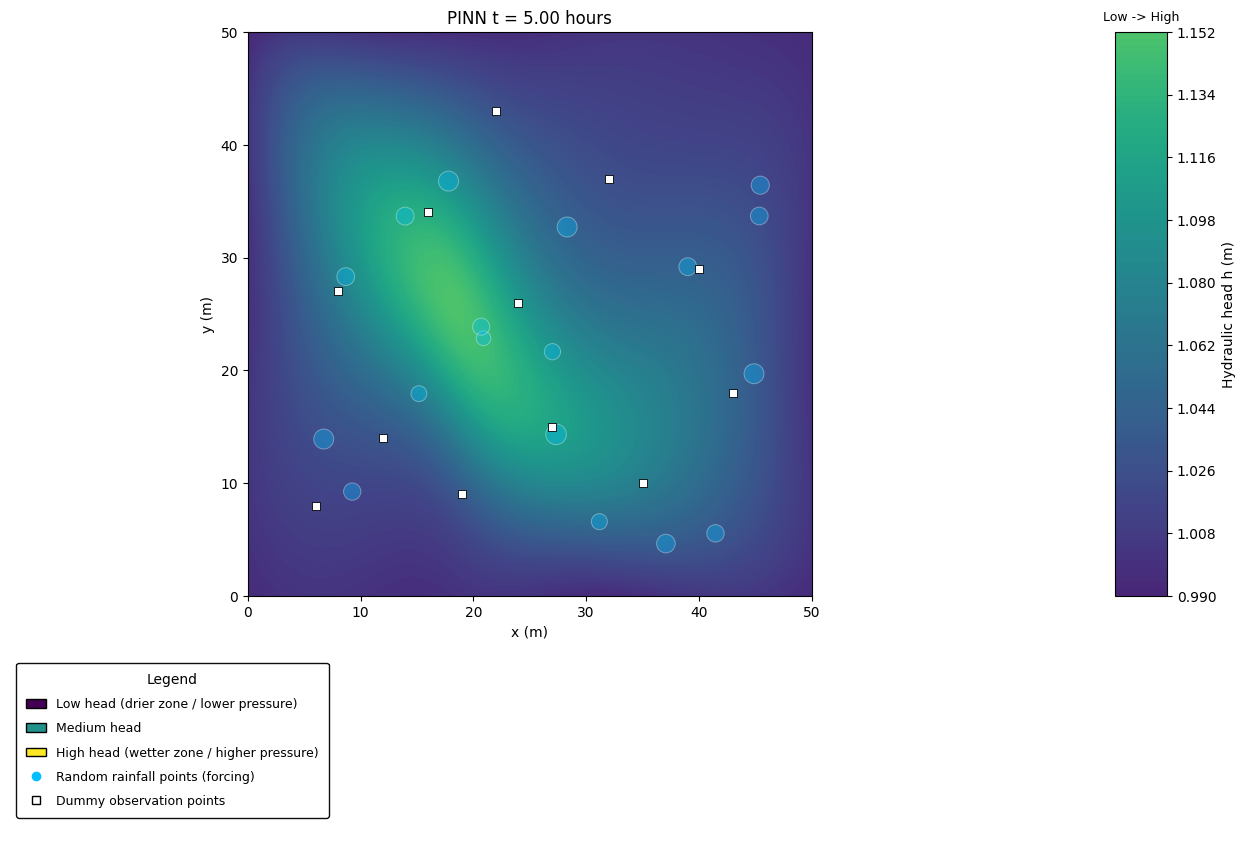

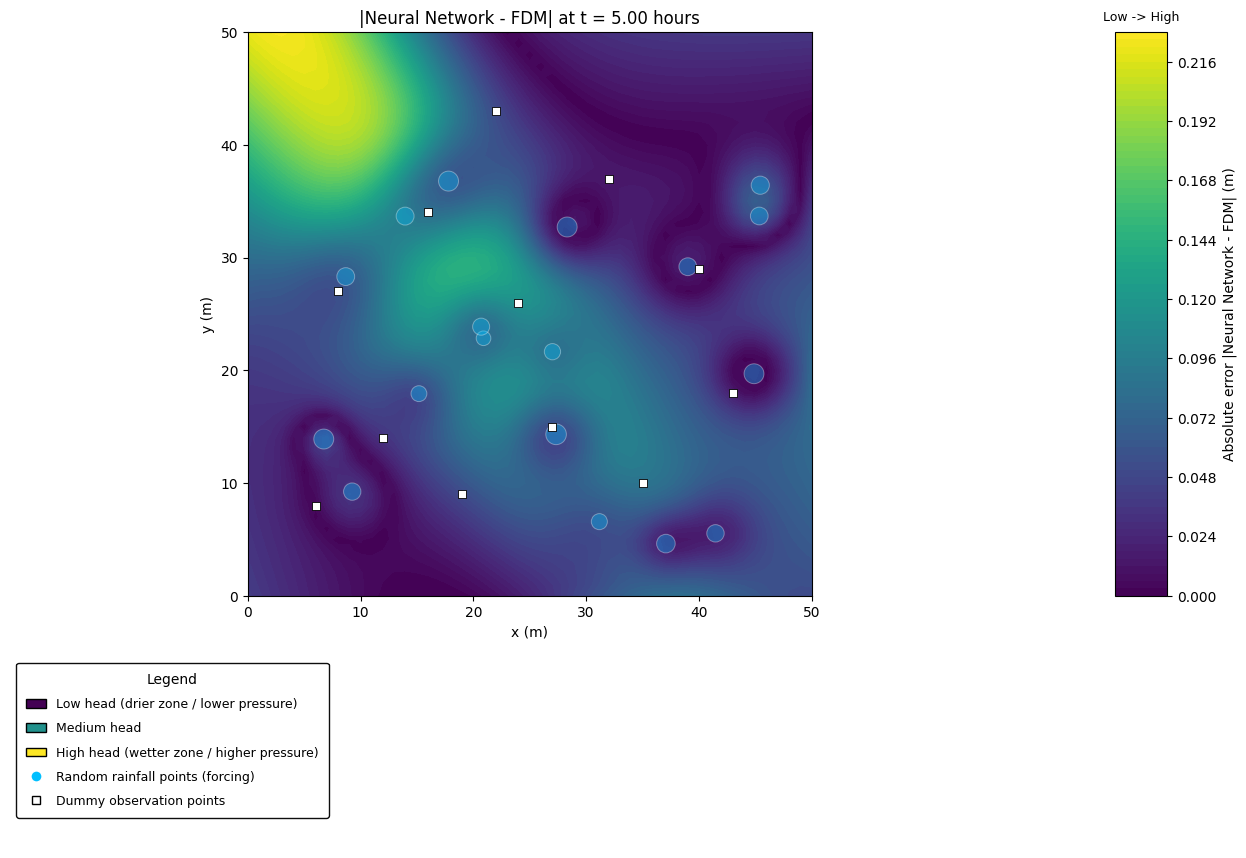

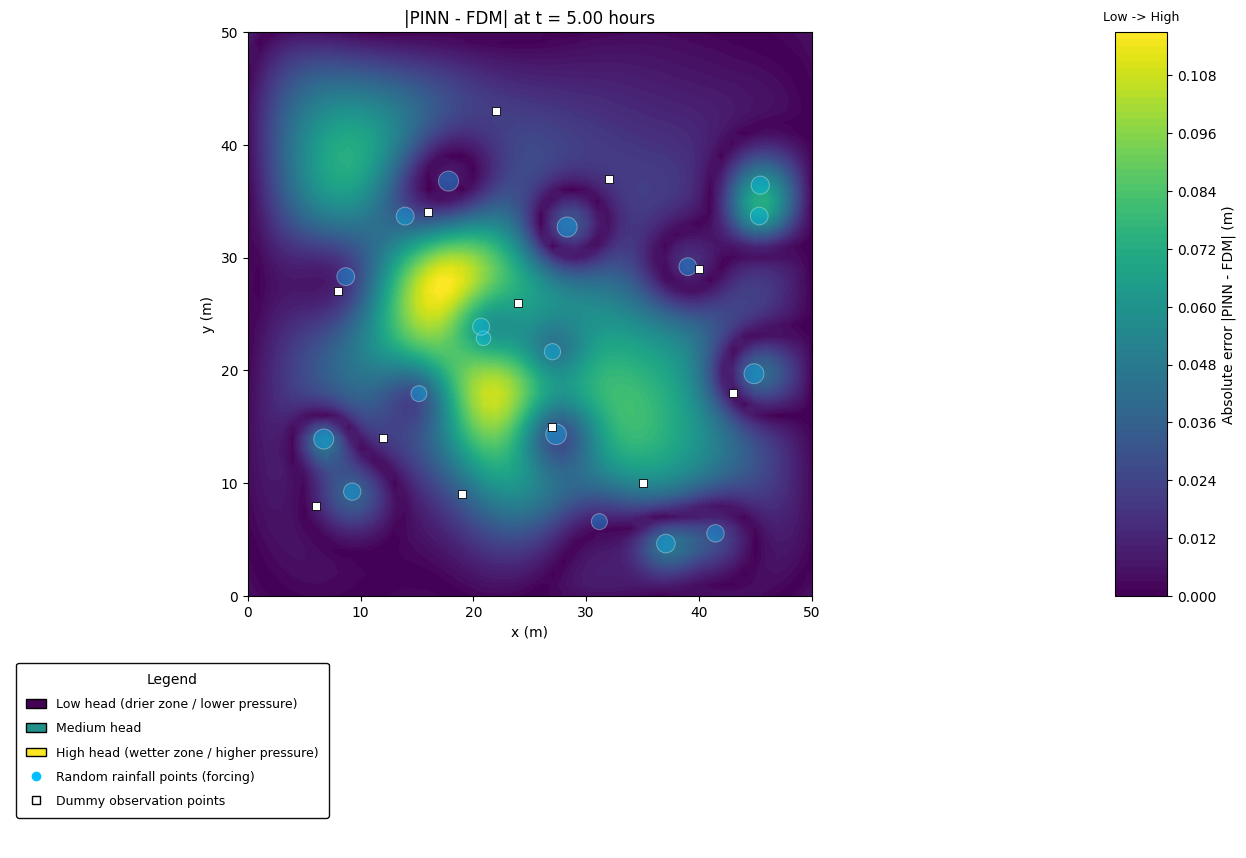

t=5.00 hours | NN -> RMSE=0.080124, MAE=0.061965, MAX=0.225699 | PINN -> RMSE=0.038053, MAE=0.027737, MAX=0.116877


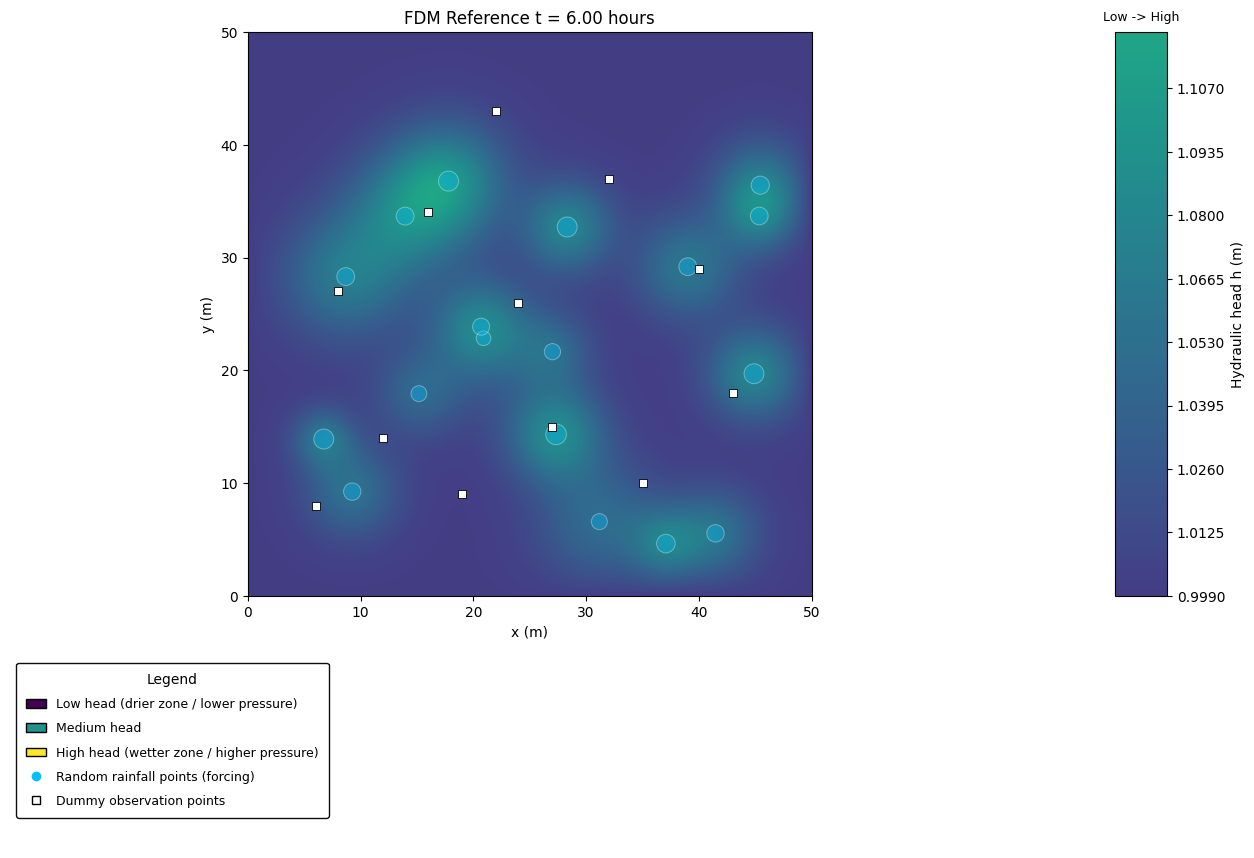

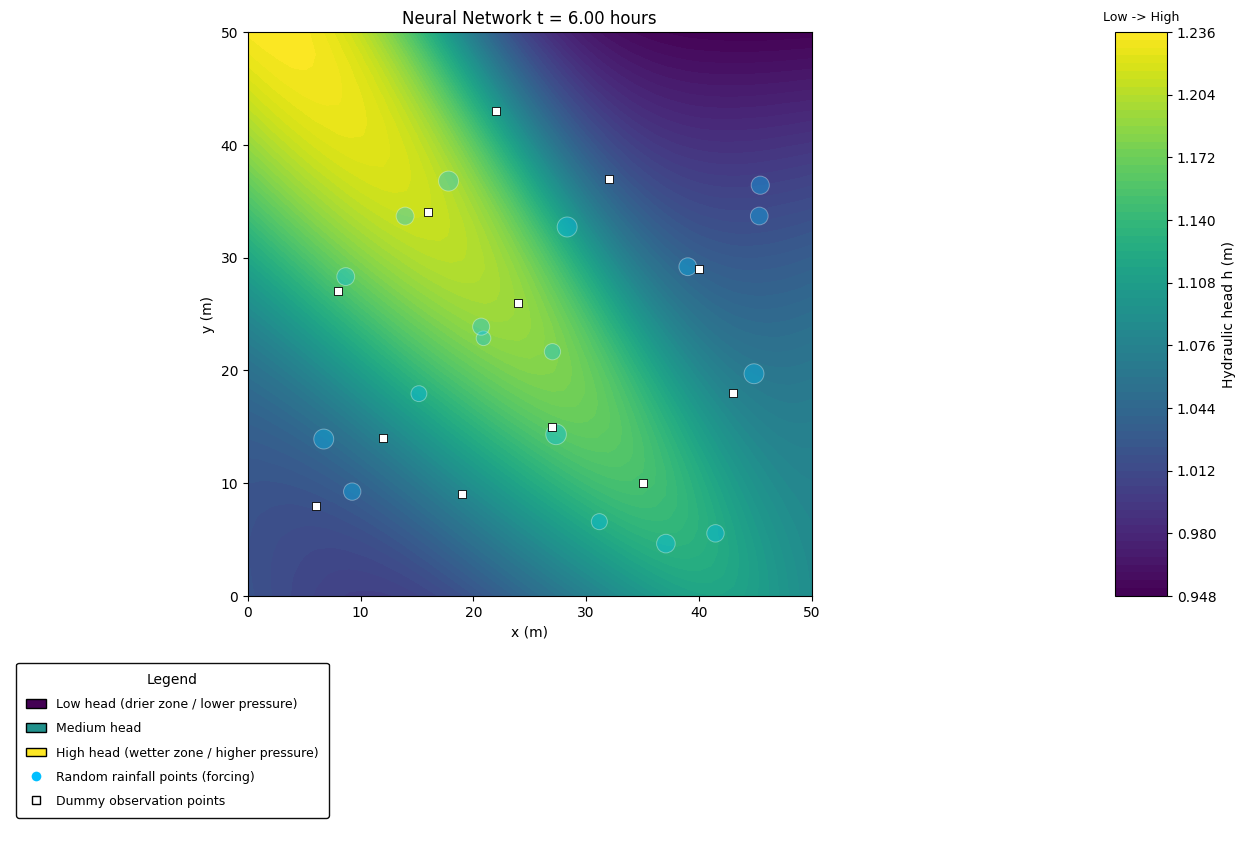

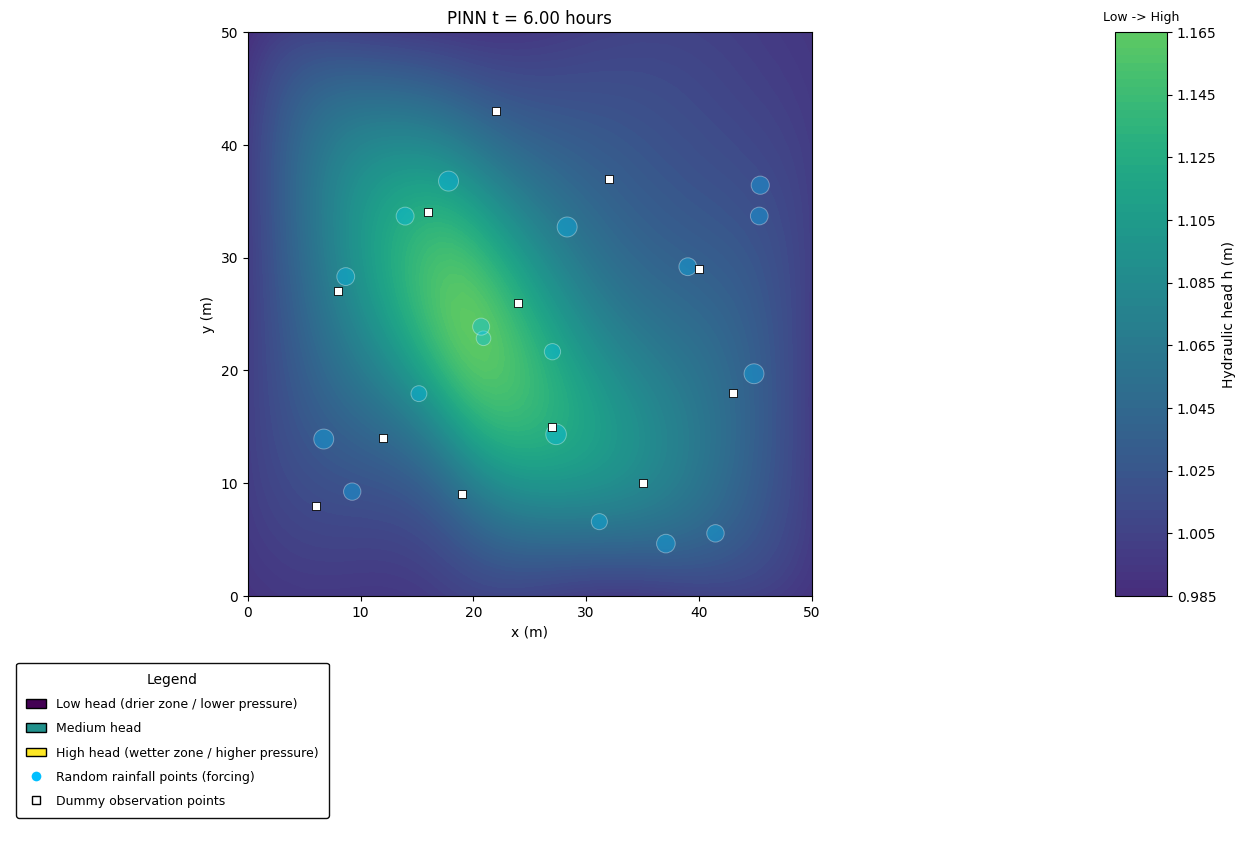

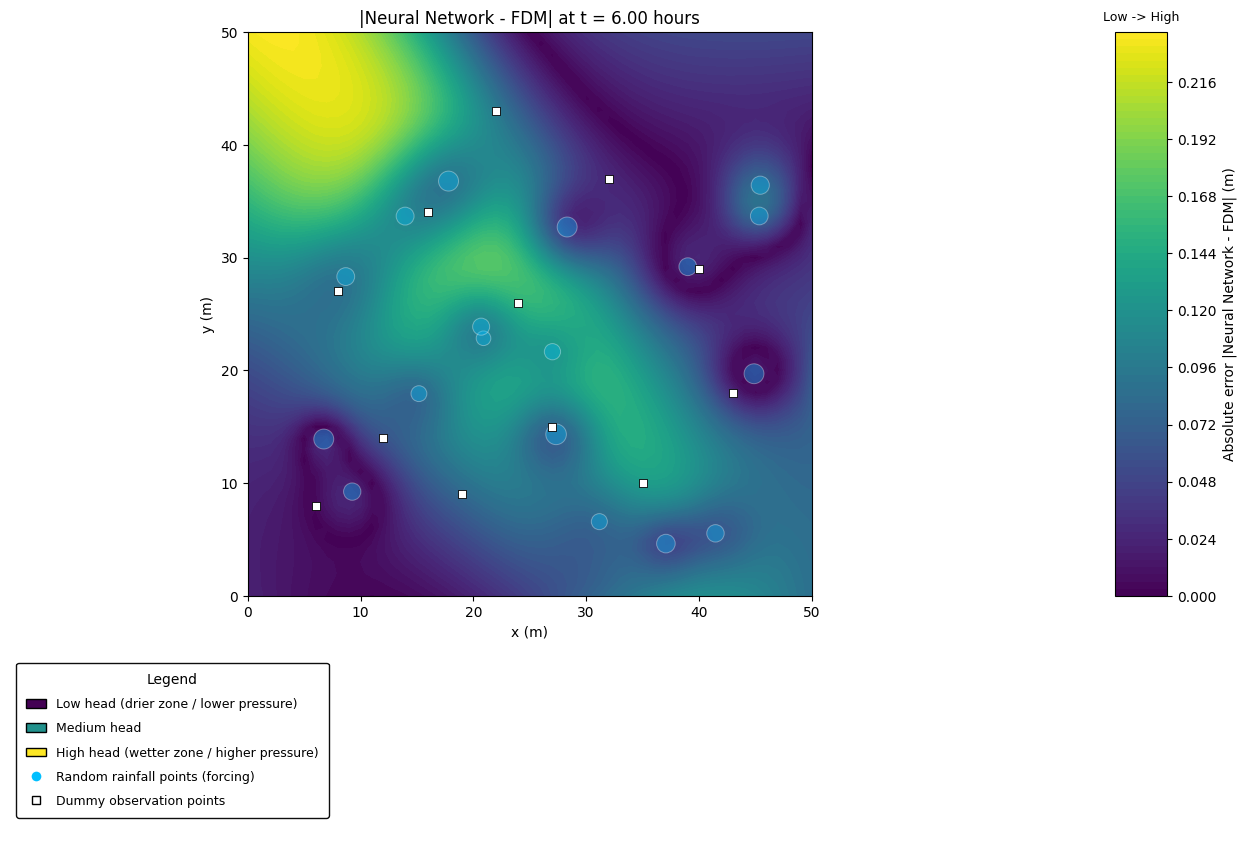

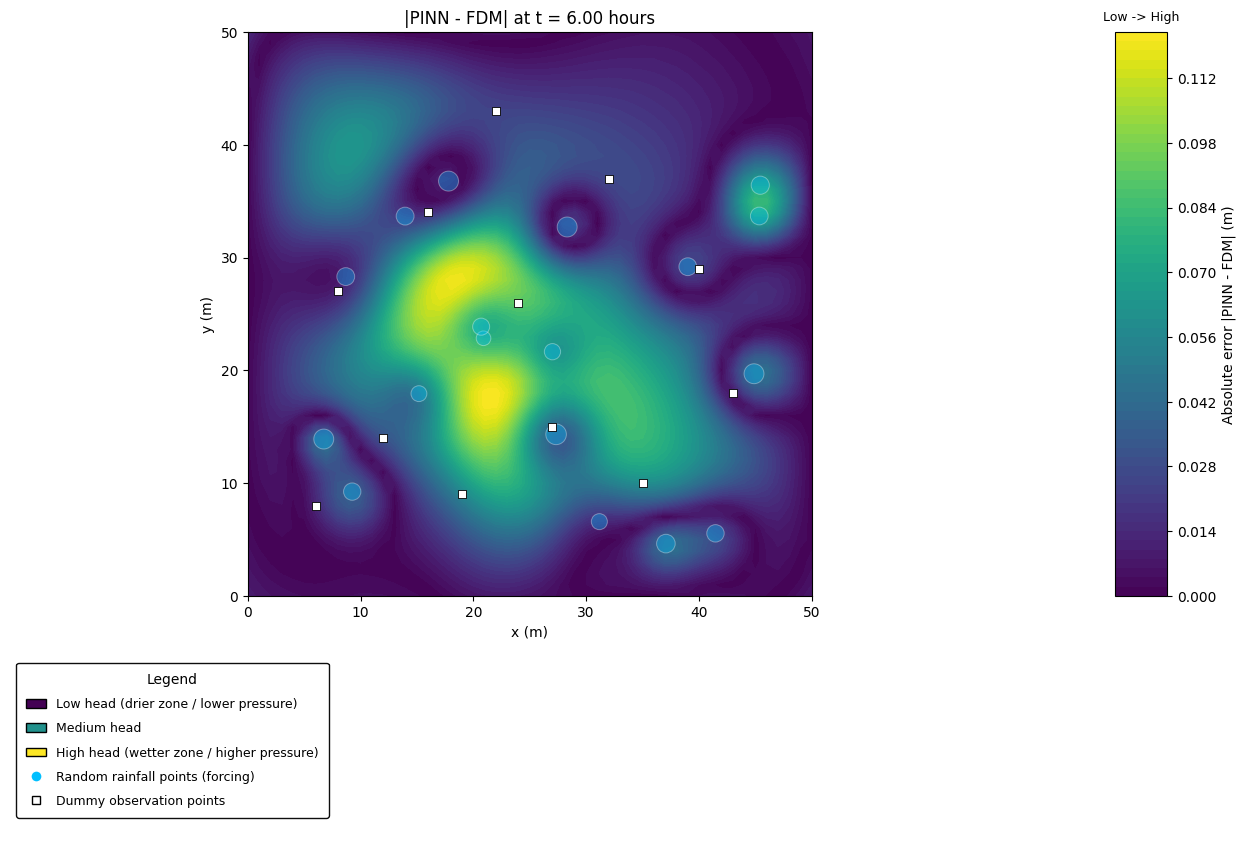

t=6.00 hours | NN -> RMSE=0.101996, MAE=0.083580, MAX=0.235691 | PINN -> RMSE=0.042371, MAE=0.030920, MAX=0.121605

Average RMSE over the hour 4-6 prediction horizon:
Neural Network: 0.079740
PINN          : 0.037049
Better model in this evaluation: PINN


In [109]:
forecast_hours = [4.0, 5.0, 6.0]
comparison_rows = []

print('Evaluating the next 3-hour prediction horizon against the FDM reference:')
for t_eval in forecast_hours:
    idx_eval = nearest_time_index(t_eval)
    t_eval_used = float(t_arr[idx_eval])
    h_ref_eval = h_fdm[idx_eval]
    h_nn_eval = predict_neural_network(nn_model, t_eval_used)
    h_pinn_eval = predict_pinn(pinn_model, t_eval_used)

    nn_metrics = regression_metrics(h_ref_eval, h_nn_eval)
    pinn_metrics = regression_metrics(h_ref_eval, h_pinn_eval)
    comparison_rows.append((t_eval_used, nn_metrics, pinn_metrics))

    global_vmin = float(min(np.min(h_ref_eval), np.min(h_nn_eval), np.min(h_pinn_eval)))
    global_vmax = float(max(np.max(h_ref_eval), np.max(h_nn_eval), np.max(h_pinn_eval)))

    plot_result(h_ref_eval, f"FDM Reference t = {t_eval_used:.2f} hours", vmin=global_vmin, vmax=global_vmax)
    plot_result(h_nn_eval, f"Neural Network t = {t_eval_used:.2f} hours", vmin=global_vmin, vmax=global_vmax)
    plot_result(h_pinn_eval, f"PINN t = {t_eval_used:.2f} hours", vmin=global_vmin, vmax=global_vmax)

    for model_name, field in [("Neural Network", h_nn_eval), ("PINN", h_pinn_eval)]:
        abs_err = np.abs(field - h_ref_eval)
        plot_result(
            abs_err,
            f"|{model_name} - FDM| at t = {t_eval_used:.2f} hours",
            colorbar_label=f'Absolute error |{model_name} - FDM| (m)',
        )

    print(
        f"t={t_eval_used:.2f} hours | "
        f"NN -> RMSE={nn_metrics['rmse_m']:.6f}, MAE={nn_metrics['mae_m']:.6f}, MAX={nn_metrics['max_abs_err_m']:.6f} | "
        f"PINN -> RMSE={pinn_metrics['rmse_m']:.6f}, MAE={pinn_metrics['mae_m']:.6f}, MAX={pinn_metrics['max_abs_err_m']:.6f}"
    )

nn_avg_rmse = float(np.mean([row[1]['rmse_m'] for row in comparison_rows]))
pinn_avg_rmse = float(np.mean([row[2]['rmse_m'] for row in comparison_rows]))

print()
print('Average RMSE over the hour 4-6 prediction horizon:')
print(f"Neural Network: {nn_avg_rmse:.6f}")
print(f"PINN          : {pinn_avg_rmse:.6f}")
print(f"Better model in this evaluation: {'PINN' if pinn_avg_rmse < nn_avg_rmse else 'Neural Network'}")

## 14. FDM vs Neural Network vs PINN Animation


In [110]:
from pathlib import Path
import time

base = Path.cwd()
fdm_dir = base / "frames_fdm"
nn_dir = base / "frames_nn"
pinn_dir = base / "frames_pinn"

for frame_dir in [fdm_dir, nn_dir, pinn_dir]:
    frame_dir.mkdir(exist_ok=True)

print(f"[INFO] Working dir      : {base}", flush=True)
print(f"[INFO] frames_fdm dir   : {fdm_dir}", flush=True)
print(f"[INFO] frames_nn dir    : {nn_dir}", flush=True)
print(f"[INFO] frames_pinn dir  : {pinn_dir}", flush=True)

def _reset_frame_dir(frame_dir):
    for png_file in frame_dir.glob("frame_*.png"):
        png_file.unlink()

FRAME_EXPORT_DPI = 140

def _save_frame(field, title, filename, vmin=None, vmax=None, cmap='viridis'):
    fig, ax, cax, ax_leg = _draw_field_figure(
        field,
        title,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        colorbar_label='Hydraulic head h (m)',
        legend_mode='flow',
        figsize=FRAME_FIGSIZE,
    )
    fig.savefig(str(filename), dpi=FRAME_EXPORT_DPI, facecolor='white', bbox_inches=None)
    plt.close(fig)

def _frame_indices(n_total, stride=6, max_frames=180):
    idx = list(range(0, n_total, stride))
    if len(idx) > max_frames:
        step = max(1, len(idx) // max_frames)
        idx = idx[::step]
    return idx

def _load_uniform_gif_frames(files):
    images = [np.asarray(imageio.imread(f)) for f in files]
    max_h = max(img.shape[0] for img in images)
    max_w = max(img.shape[1] for img in images)
    normalized = []
    unique_sizes = sorted({(img.shape[1], img.shape[0]) for img in images})

    for img in images:
        if img.ndim == 2:
            canvas = np.full((max_h, max_w), 255, dtype=img.dtype)
            y0 = (max_h - img.shape[0]) // 2
            x0 = (max_w - img.shape[1]) // 2
            canvas[y0:y0 + img.shape[0], x0:x0 + img.shape[1]] = img
        else:
            canvas = np.full((max_h, max_w, img.shape[2]), 255, dtype=img.dtype)
            y0 = (max_h - img.shape[0]) // 2
            x0 = (max_w - img.shape[1]) // 2
            canvas[y0:y0 + img.shape[0], x0:x0 + img.shape[1], :] = img
        normalized.append(canvas)

    if len(unique_sizes) > 1:
        print(f"[GIF] Normalized frame sizes {unique_sizes} -> {(max_w, max_h)}", flush=True)

    return normalized

def make_fdm_gif(h_fdm, t_arr, frame_dir, out_gif='fdm_animation.gif', stride=6, fps=10, vmin=None, vmax=None, max_frames=180):
    _reset_frame_dir(frame_dir)
    files = []
    vmin = float(np.min(h_fdm)) if vmin is None else float(vmin)
    vmax = float(np.max(h_fdm)) if vmax is None else float(vmax)
    idx_list = _frame_indices(len(t_arr), stride=stride, max_frames=max_frames)

    print(f"[FDM] Start | total_t={len(t_arr)} | frames={len(idx_list)}", flush=True)
    t0 = time.time()
    for k, idx in enumerate(idx_list, 1):
        fname = frame_dir / f'frame_{idx:04d}.png'
        _save_frame(h_fdm[idx], f'FDM: t = {t_arr[idx]:.2f} hours', fname, vmin=vmin, vmax=vmax, cmap='viridis')
        files.append(str(fname))
        if (k % 20 == 0) or (k == len(idx_list)):
            print(f"[FDM] frame {k}/{len(idx_list)}", flush=True)

    if not files:
        raise RuntimeError('No FDM frames were created.')

    images = _load_uniform_gif_frames(files)
    out_path = base / out_gif
    imageio.mimsave(str(out_path), images, fps=fps, loop=0, subrectangles=False)
    print(f"[FDM] Done in {time.time()-t0:.1f}s | GIF: {out_path} | frames={len(files)}", flush=True)
    return str(out_path)

def make_prediction_gif(predict_fn, label, frame_dir, t_arr, out_gif, stride=6, fps=10, vmin=None, vmax=None, max_frames=180):
    _reset_frame_dir(frame_dir)
    files = []
    idx_list = _frame_indices(len(t_arr), stride=stride, max_frames=max_frames)
    use_times = [float(t_arr[idx]) for idx in idx_list]

    print(f"[{label}] Start predict | frames={len(use_times)}", flush=True)
    t0 = time.time()
    fields = [predict_fn(tt) for tt in use_times]
    stack = np.stack(fields, axis=0)

    vmin = float(np.min(stack)) if vmin is None else float(vmin)
    vmax = float(np.max(stack)) if vmax is None else float(vmax)

    for k, (idx, field) in enumerate(zip(idx_list, fields), 1):
        fname = frame_dir / f'frame_{idx:04d}.png'
        _save_frame(field, f'{label}: t = {t_arr[idx]:.2f} hours', fname, vmin=vmin, vmax=vmax, cmap='viridis')
        files.append(str(fname))
        if (k % 20 == 0) or (k == len(idx_list)):
            print(f"[{label}] frame {k}/{len(idx_list)}", flush=True)

    if not files:
        raise RuntimeError(f'No {label} frames were created.')

    images = _load_uniform_gif_frames(files)
    out_path = base / out_gif
    imageio.mimsave(str(out_path), images, fps=fps, loop=0, subrectangles=False)
    print(f"[{label}] Done in {time.time()-t0:.1f}s | GIF: {out_path} | frames={len(files)}", flush=True)
    return str(out_path)

try:
    sample_idx = _frame_indices(len(t_arr), stride=6, max_frames=120)
    sample_times = [float(t_arr[i]) for i in sample_idx]
    fdm_sample = h_fdm[sample_idx]
    nn_sample = np.stack([predict_neural_network(nn_model, tt) for tt in sample_times], axis=0)
    pinn_sample = np.stack([predict_pinn(pinn_model, tt) for tt in sample_times], axis=0)

    global_vmin = float(min(np.min(fdm_sample), np.min(nn_sample), np.min(pinn_sample)))
    global_vmax = float(max(np.max(fdm_sample), np.max(nn_sample), np.max(pinn_sample)))

    fdm_gif = make_fdm_gif(
        h_fdm,
        t_arr,
        frame_dir=fdm_dir,
        out_gif='fdm_animation.gif',
        stride=6,
        fps=10,
        vmin=global_vmin,
        vmax=global_vmax,
        max_frames=180,
    )
    nn_gif = make_prediction_gif(
        lambda tt: predict_neural_network(nn_model, tt),
        'Neural Network',
        nn_dir,
        t_arr,
        out_gif='nn_animation.gif',
        stride=6,
        fps=10,
        vmin=global_vmin,
        vmax=global_vmax,
        max_frames=180,
    )
    pinn_gif = make_prediction_gif(
        lambda tt: predict_pinn(pinn_model, tt),
        'PINN',
        pinn_dir,
        t_arr,
        out_gif='pinn_animation.gif',
        stride=6,
        fps=10,
        vmin=global_vmin,
        vmax=global_vmax,
        max_frames=180,
    )

    print(f"[INFO] Number of FDM frames : {len(list(fdm_dir.glob('frame_*.png')))}", flush=True)
    print(f"[INFO] Number of NN frames  : {len(list(nn_dir.glob('frame_*.png')))}", flush=True)
    print(f"[INFO] Number of PINN frames: {len(list(pinn_dir.glob('frame_*.png')))}", flush=True)
    print(f"[INFO] GIF FDM : {fdm_gif}", flush=True)
    print(f"[INFO] GIF NN  : {nn_gif}", flush=True)
    print(f"[INFO] GIF PINN: {pinn_gif}", flush=True)
except Exception:
    print('[ERROR] GIF generation failed', flush=True)
    traceback.print_exc()


[INFO] Working dir      : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow
[INFO] frames_fdm dir   : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\frames_fdm
[INFO] frames_nn dir    : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\frames_nn
[INFO] frames_pinn dir  : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\frames_pinn
[FDM] Start | total_t=61 | frames=11
[FDM] frame 11/11
[FDM] Done in 3.1s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\fdm_animation.gif | frames=11
[Neural Network] Start predict | frames=11
[Neural Network] frame 11/11
[Neural Network] Done in 2.9s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\nn_animation.gif | frames=11
[PINN] Start predict | frames=11
[PINN] frame 11/11
[PINN] Done in 3.2s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\pinn_animation.gif | frames=11
[INFO] Number of FDM frames : 11
[INFO] Number of NN frames  : 11
[INFO] Number of PINN frames: 11
[INFO] GIF FDM : c:\Users\G

## 15. Computational Evaluation


In [111]:
forecast_hours = [4.0, 5.0, 6.0]
summary_rows = []

for t_eval in forecast_hours:
    idx_eval = nearest_time_index(t_eval)
    t_eval_used = float(t_arr[idx_eval])
    h_ref_eval = h_fdm[idx_eval]
    h_nn_eval = predict_neural_network(nn_model, t_eval_used)
    h_pinn_eval = predict_pinn(pinn_model, t_eval_used)

    nn_metrics = regression_metrics(h_ref_eval, h_nn_eval)
    pinn_metrics = regression_metrics(h_ref_eval, h_pinn_eval)
    summary_rows.append((t_eval_used, nn_metrics, pinn_metrics))

print('Summary of prediction evaluation for hours 4-6 against FDM:')
for t_eval_used, nn_metrics, pinn_metrics in summary_rows:
    winner = 'PINN' if pinn_metrics['rmse_m'] < nn_metrics['rmse_m'] else 'Neural Network'
    print(
        f"t={t_eval_used:.2f} hours -> "
        f"NN(RMSE={nn_metrics['rmse_m']:.6f}, MAE={nn_metrics['mae_m']:.6f}) | "
        f"PINN(RMSE={pinn_metrics['rmse_m']:.6f}, MAE={pinn_metrics['mae_m']:.6f}) | "
        f"better: {winner}"
    )

nn_avg_rmse = float(np.mean([row[1]['rmse_m'] for row in summary_rows]))
pinn_avg_rmse = float(np.mean([row[2]['rmse_m'] for row in summary_rows]))
overall_winner = 'PINN' if pinn_avg_rmse < nn_avg_rmse else 'Neural Network'

print(f"Average NN RMSE   (hours 4-6): {nn_avg_rmse:.6f}")
print(f"Average PINN RMSE (hours 4-6): {pinn_avg_rmse:.6f}")
print(f"Best model for the next 3-hour prediction in this setup: {overall_winner}")

for gif_name in ['fdm_animation.gif', 'nn_animation.gif', 'pinn_animation.gif']:
    gif_path = Path(gif_name)
    if gif_path.exists():
        print(f"{gif_name}: {gif_path.stat().st_size / 1024:.1f} KB")

Summary of prediction evaluation for hours 4-6 against FDM:
t=4.00 hours -> NN(RMSE=0.057100, MAE=0.041899) | PINN(RMSE=0.030723, MAE=0.022612) | better: PINN
t=5.00 hours -> NN(RMSE=0.080124, MAE=0.061965) | PINN(RMSE=0.038053, MAE=0.027737) | better: PINN
t=6.00 hours -> NN(RMSE=0.101996, MAE=0.083580) | PINN(RMSE=0.042371, MAE=0.030920) | better: PINN
Average NN RMSE   (hours 4-6): 0.079740
Average PINN RMSE (hours 4-6): 0.037049
Best model for the next 3-hour prediction in this setup: PINN
fdm_animation.gif: 412.6 KB
nn_animation.gif: 489.4 KB
pinn_animation.gif: 412.7 KB


## 16. Further Development

Support this repository by giving it a star.

Thank you.

*If you find it useful, you can also support me with a coffee.*

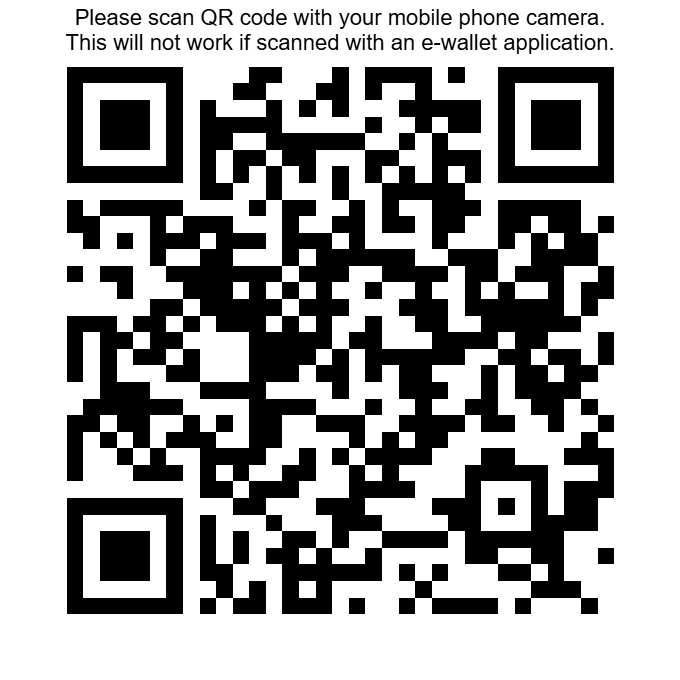

[Buy me a cup of coffee.](https://checkout.xendit.co/donation/ezieqel)
